# Proyek Akhir: Menyelesaikan Permasalahan Jaya Jaya Institut

- Nama: Istia Budi
- Email: istiabudi@gmail.com
- Id Dicoding: istiabudi73

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

In [3]:
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv'
data_df = pd.read_csv(url, delimiter=';')
data_df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


## Data Understanding

In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
data_df.describe(include='all')

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


## Data Preparation / Preprocessing

### Handling Missing Values

In [6]:
print(data_df.isna().sum())

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


### Handling Duplicate Data

In [7]:
print(data_df.duplicated().sum())

0


### Num to Label Decode

In [8]:
import pandas as pd

# Dictionary untuk mapping nilai numerik ke label teks
marital_status_map = {
    1: "single",
    2: "married",
    3: "widower",
    4: "divorced",
    5: "facto union",
    6: "legally separated"
}

application_mode_map = {
    1: "1st phase - general contingent",
    2: "Ordinance No. 612/93",
    5: "1st phase - special contingent (Azores Island)",
    7: "Holders of other higher courses",
    10: "Ordinance No. 854-B/99",
    15: "International student (bachelor)",
    16: "1st phase - special contingent (Madeira Island)",
    17: "2nd phase - general contingent",
    18: "3rd phase - general contingent",
    26: "Ordinance No. 533-A/99, item b2) (Different Plan)",
    27: "Ordinance No. 533-A/99, item b3 (Other Institution)",
    39: "Over 23 years old",
    42: "Transfer",
    43: "Change of course",
    44: "Technological specialization diploma holders",
    51: "Change of institution/course",
    53: "Short cycle diploma holders",
    57: "Change of institution/course (International)"
}

application_order_map = {
    0: "first choice",
    1: "1st choice",
    2: "2nd choice",
    3: "3rd choice",
    4: "4th choice",
    5: "5th choice",
    6: "6th choice",
    7: "7th choice",
    8: "8th choice",
    9: "9th choice"
}

course_map = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening attendance)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening attendance)"
}

attendance_map = {
    1: "daytime",
    0: "evening"
}

prev_qualification_map = {
    1: "Secondary education",
    2: "Higher education - bachelor's degree",
    3: "Higher education - degree",
    4: "Higher education - master's",
    5: "Higher education - doctorate",
    6: "Frequency of higher education",
    9: "12th year of schooling - not completed",
    10: "11th year of schooling - not completed",
    12: "Other - 11th year of schooling",
    14: "10th year of schooling",
    15: "10th year of schooling - not completed",
    19: "Basic education 3rd cycle (9th/10th/11th year) or equiv.",
    38: "Basic education 2nd cycle (6th/7th/8th year) or equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)"
}

nationality_map = {
    1: "Portuguese",
    2: "German",
    6: "Spanish",
    11: "Italian",
    13: "Dutch",
    14: "English",
    17: "Lithuanian",
    21: "Angolan",
    22: "Cape Verdean",
    24: "Guinean",
    25: "Mozambican",
    26: "Santomean",
    32: "Turkish",
    41: "Brazilian",
    62: "Romanian",
    100: "Moldova (Republic of)",
    101: "Mexican",
    103: "Ukrainian",
    105: "Russian",
    108: "Cuban",
    109: "Colombian"
}

mother_qualification_map = {
    1: "Secondary Education - 12th Year of Schooling or Eq.",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    18: "General commerce course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.",
    22: "Technical-professional course",
    26: "7th year of schooling",
    27: "2nd cycle of the general high school course",
    29: "9th Year of Schooling - Not Completed",
    30: "8th year of schooling",
    34: "Unknown",
    35: "Can't read or write",
    36: "Can read without having a 4th year of schooling",
    37: "Basic education 1st cycle (4th/5th year) or equiv.",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    41: "Specialized higher studies course",
    42: "Professional higher technical course",
    43: "Higher Education - Master (2nd cycle)",
    44: "Higher Education - Doctorate (3rd cycle)"
}

father_qualification_map = {
    1: "Secondary Education - 12th Year of Schooling or Eq.",
    2: "Higher Education - Bachelor's Degree",
    3: "Higher Education - Degree",
    4: "Higher Education - Master's",
    5: "Higher Education - Doctorate",
    6: "Frequency of Higher Education",
    9: "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    13: "2nd year complementary high school course",
    14: "10th Year of Schooling",
    18: "General commerce course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.",
    20: "Complementary High School Course",
    22: "Technical-professional course",
    25: "Complementary High School Course - not concluded",
    26: "7th year of schooling",
    27: "2nd cycle of the general high school course",
    29: "9th Year of Schooling - Not Completed",
    30: "8th year of schooling",
    31: "General Course of Administration and Commerce",
    33: "Supplementary Accounting and Administration",
    34: "Unknown",
    35: "Can't read or write",
    36: "Can read without having a 4th year of schooling",
    37: "Basic education 1st cycle (4th/5th year) or equiv.",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    41: "Specialized higher studies course",
    42: "Professional higher technical course",
    43: "Higher Education - Master (2nd cycle)",
    44: "Higher Education - Doctorate (3rd cycle)"
}

mother_occupation_map = {
    0: "Student",
    1: "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    2: "Specialists in Intellectual and Scientific Activities",
    3: "Intermediate Level Technicians and Professions",
    4: "Administrative staff",
    5: "Personal Services, Security and Safety Workers and Sellers",
    6: "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7: "Skilled Workers in Industry, Construction and Craftsmen",
    8: "Installation and Machine Operators and Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "(blank)",
    122: "Health professionals",
    123: "Teachers",
    125: "Specialists in information and communication technologies (ICT)",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Technicians and professionals, of intermediate level of health",
    134: "Intermediate level technicians from legal, social, sports, cultural and similar services",
    141: "Office workers, secretaries in general and data processing operators",
    143: "Data, accounting, statistical, financial services and registry-related operators",
    144: "Other administrative support staff",
    151: "Personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    171: "Skilled construction workers and the like, except electricians",
    173: "Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    191: "Cleaning workers",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants"
}

father_occupation_map = {
    0: "Student",
    1: "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    2: "Specialists in Intellectual and Scientific Activities",
    3: "Intermediate Level Technicians and Professions",
    4: "Administrative staff",
    5: "Personal Services, Security and Safety Workers and Sellers",
    6: "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7: "Skilled Workers in Industry, Construction and Craftsmen",
    8: "Installation and Machine Operators and Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "(blank)",
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces personnel",
    112: "Directors of administrative and commercial services",
    114: "Hotel, catering, trade and other services directors",
    121: "Specialists in the physical sciences, mathematics, engineering and related techniques",
    122: "Health professionals",
    123: "Teachers",
    124: "Specialists in finance, accounting, administrative organization, public and commercial relations",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Technicians and professionals, of intermediate level of health",
    134: "Intermediate level technicians from legal, social, sports, cultural and similar services",
    135: "Information and communication technology technicians",
    141: "Office workers, secretaries in general and data processing operators",
    143: "Data, accounting, statistical, financial services and registry-related operators",
    144: "Other administrative support staff",
    151: "Personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    154: "Protection and security services personnel",
    161: "Market-oriented farmers and skilled agricultural and animal production workers",
    163: "Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence",
    171: "Skilled construction workers and the like, except electricians",
    172: "Skilled workers in metallurgy, metalworking and similar",
    174: "Skilled workers in electricity and electronics",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    181: "Fixed plant and machine operators",
    182: "Assembly workers",
    183: "Vehicle drivers and mobile equipment operators",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants",
    195: "Street vendors (except food) and street service providers"
}

displaced_map = {
    1: "Yes",
    0: "No"
}

educational_special_needs_map = {
    1: "Yes",
    0: "No"
}

debtor_map = {
    1: "Yes",
    0: "No"
}

tuition_fees_up_to_date_map = {
    1: "Yes",
    0: "No"
}

gender_map = {
    1: "Male",
    0: "Female"
}

scholarship_map = {
    1: "Yes",
    0: "No"
}

international_map = {
    1: "Yes",
    0: "No"
}

categorical_mappings = {
    'Marital_status': marital_status_map,
    'Application_mode': application_mode_map,
    'Application_order': application_order_map,
    'Course': course_map,
    'Daytime_evening_attendance': attendance_map,
    'Previous_qualification': prev_qualification_map,
    'Nacionality': nationality_map,
    'Mothers_qualification': mother_qualification_map,
    'Fathers_qualification': father_qualification_map,
    'Mothers_occupation': mother_occupation_map,
    'Fathers_occupation': father_occupation_map,
    'Displaced': displaced_map,
    'Educational_special_needs': educational_special_needs_map,
    'Debtor': debtor_map,
    'Tuition_fees_up_to_date': tuition_fees_up_to_date_map,
    'Gender': gender_map,
    'Scholarship_holder': scholarship_map,
    'International': international_map
}

def apply_categorical_mappings(df):
    df = df.copy()
    for column, mapping in categorical_mappings.items():
        if column in df.columns:
            df[column] = df[column].replace(mapping)
        else:
            print(f"Warning: Column '{column}' not found in DataFrame")
    return df

# Contoh penggunaan dengan DataFrame
# Misalkan Anda memiliki DataFrame 'data_df'
# data_df = pd.read_csv('your_data.csv')
data_df_mapped = apply_categorical_mappings(data_df)

In [9]:
data_df_mapped.to_csv('data_mapped.csv')

### Exploration Data Analysis

In [10]:
numerical_features, categorical_features = [], []

for feature in data_df_mapped.columns:
    if data_df_mapped[feature].dtype == 'object':
        categorical_features.append(feature)
    else:
        numerical_features.append(feature)

In [11]:
categorical_features

['Marital_status',
 'Application_mode',
 'Application_order',
 'Course',
 'Daytime_evening_attendance',
 'Previous_qualification',
 'Nacionality',
 'Mothers_qualification',
 'Fathers_qualification',
 'Mothers_occupation',
 'Fathers_occupation',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'International',
 'Status']

#### Univariate Categorical Analysis

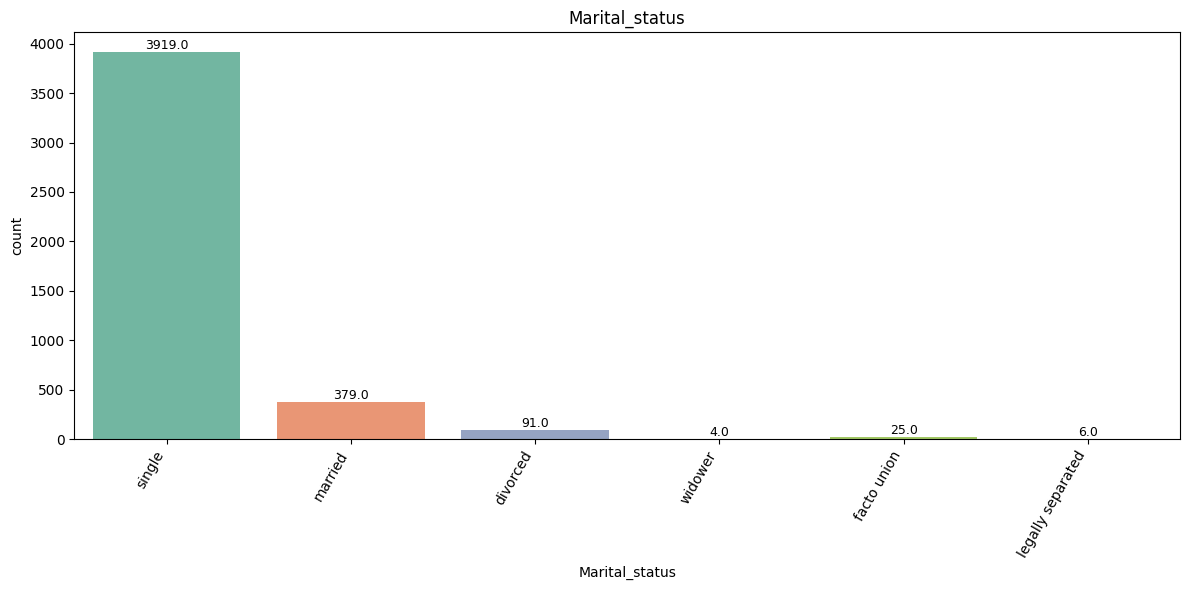

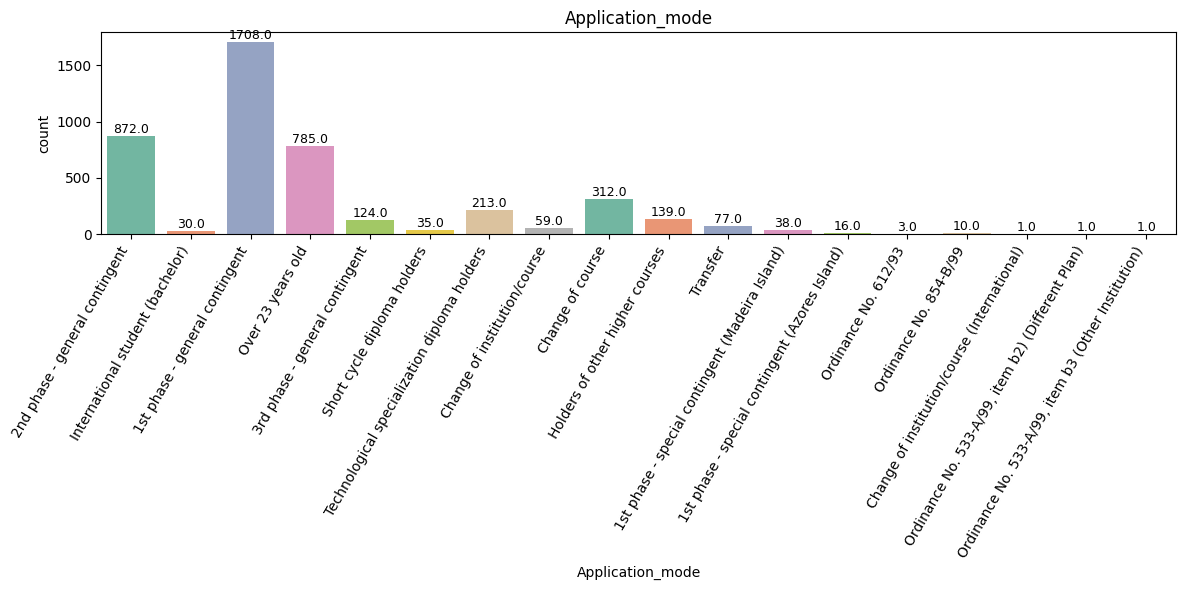

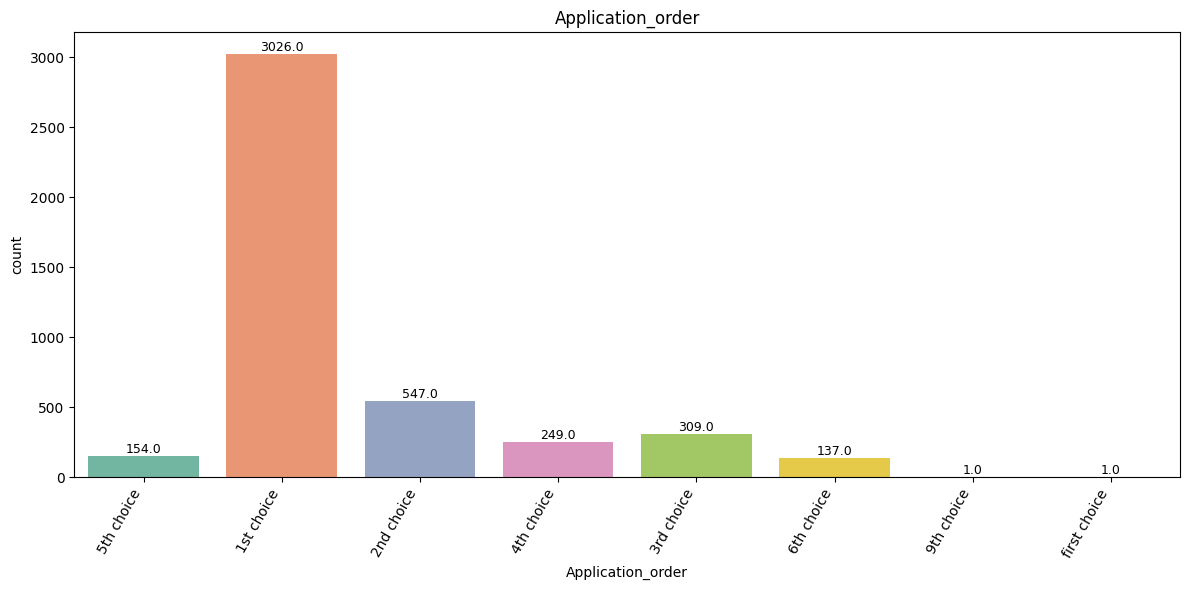

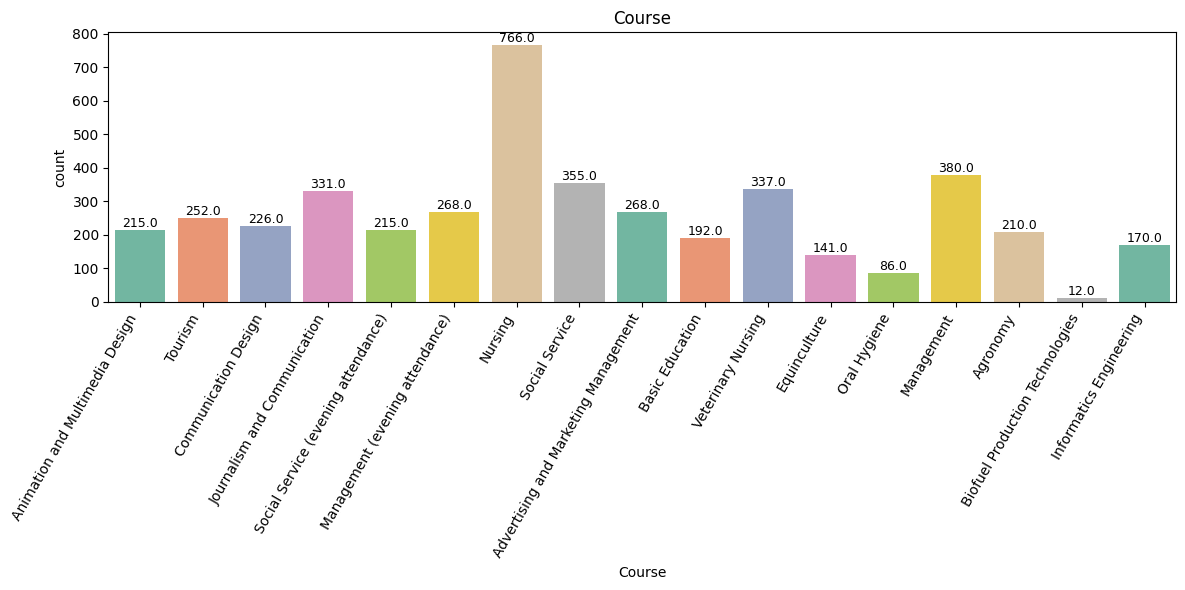

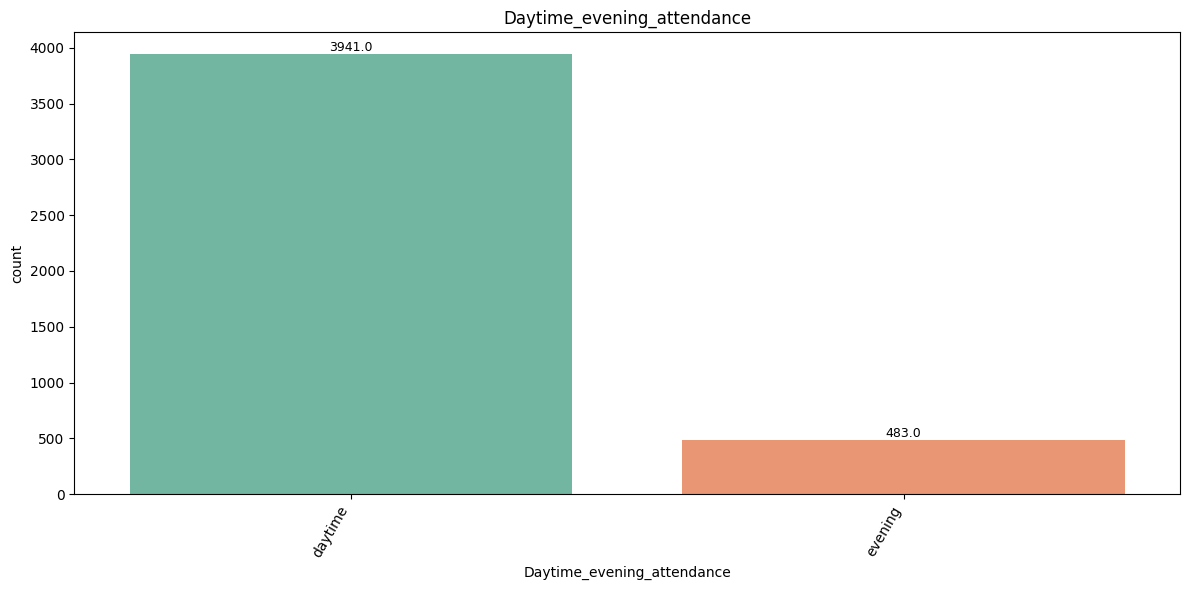

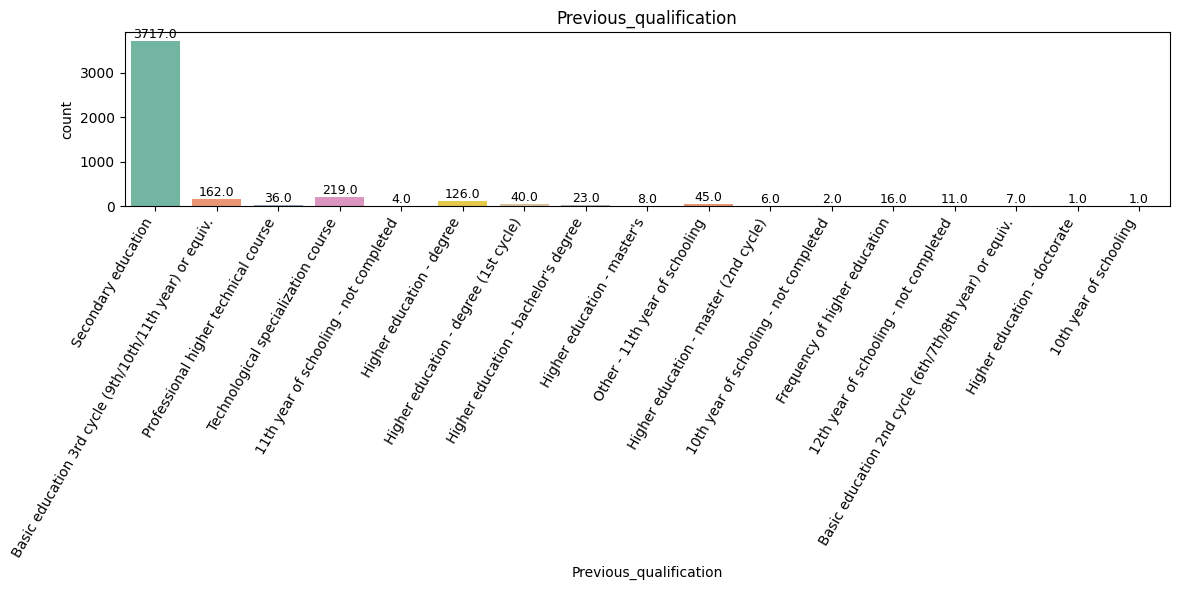

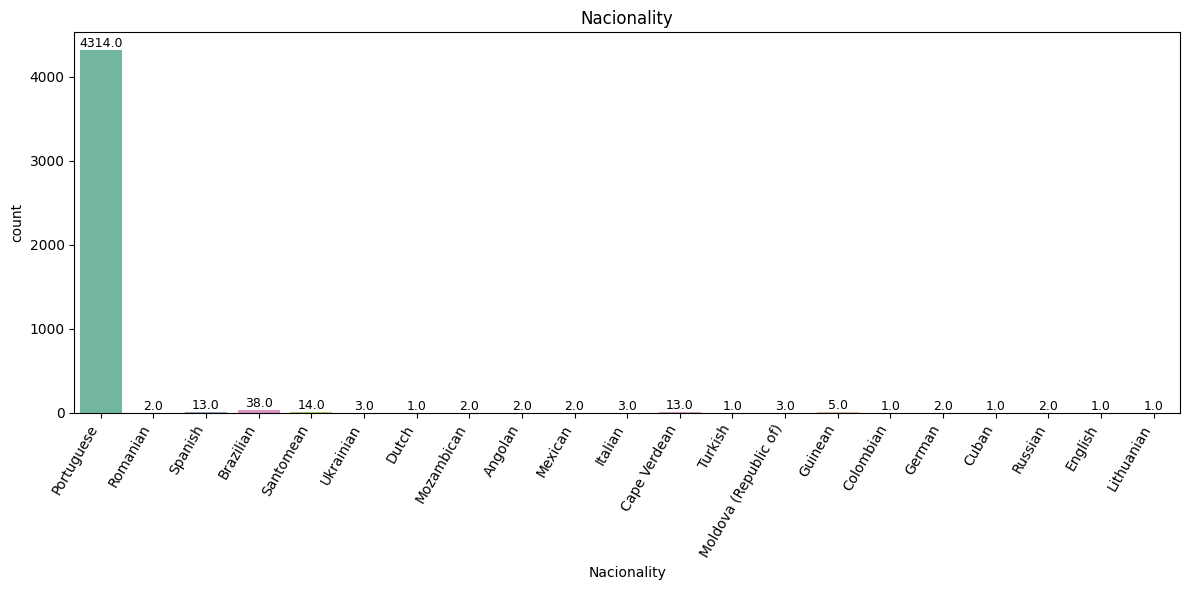

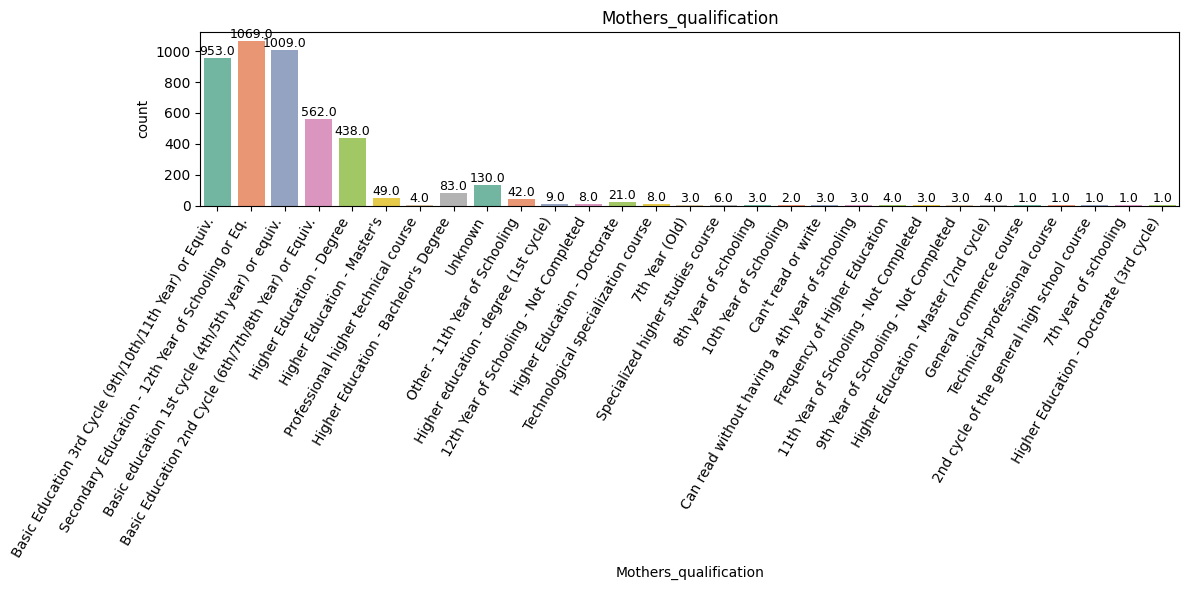

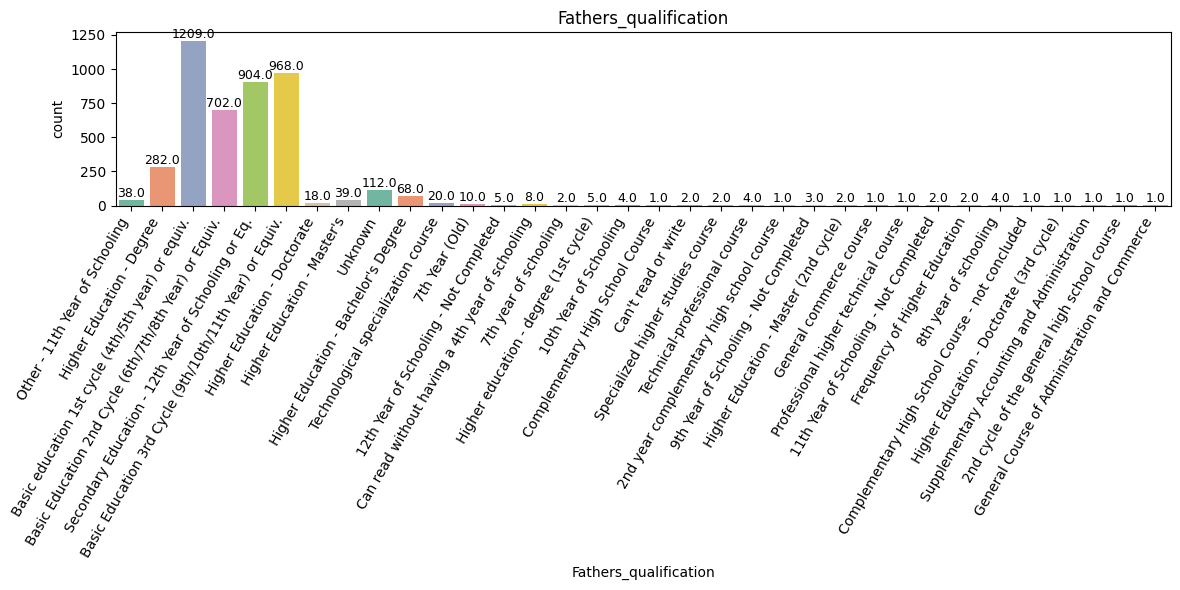

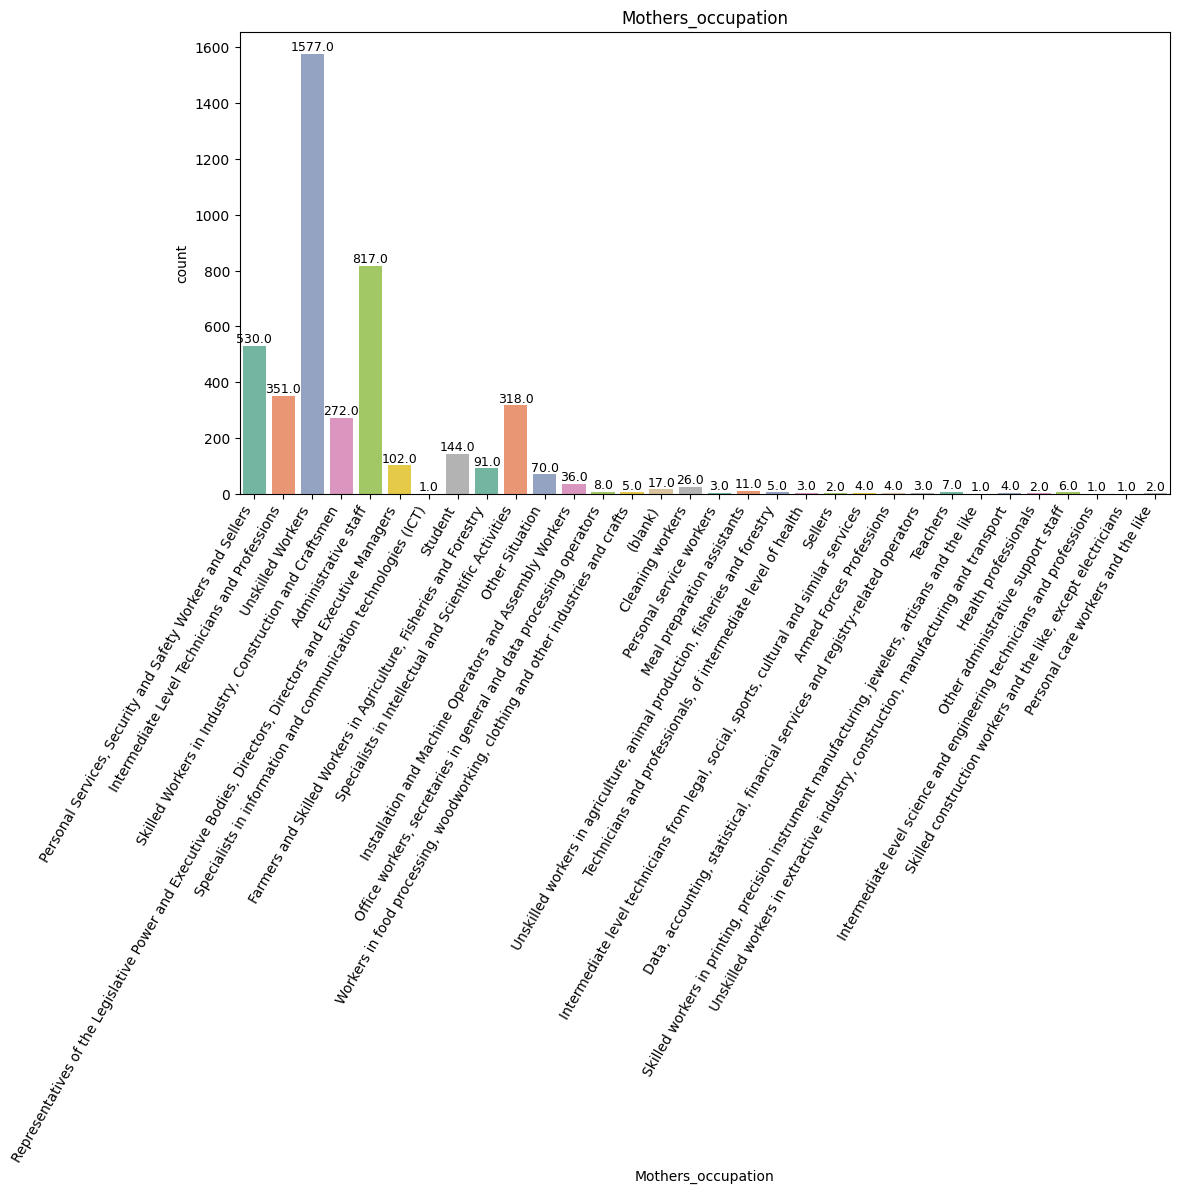

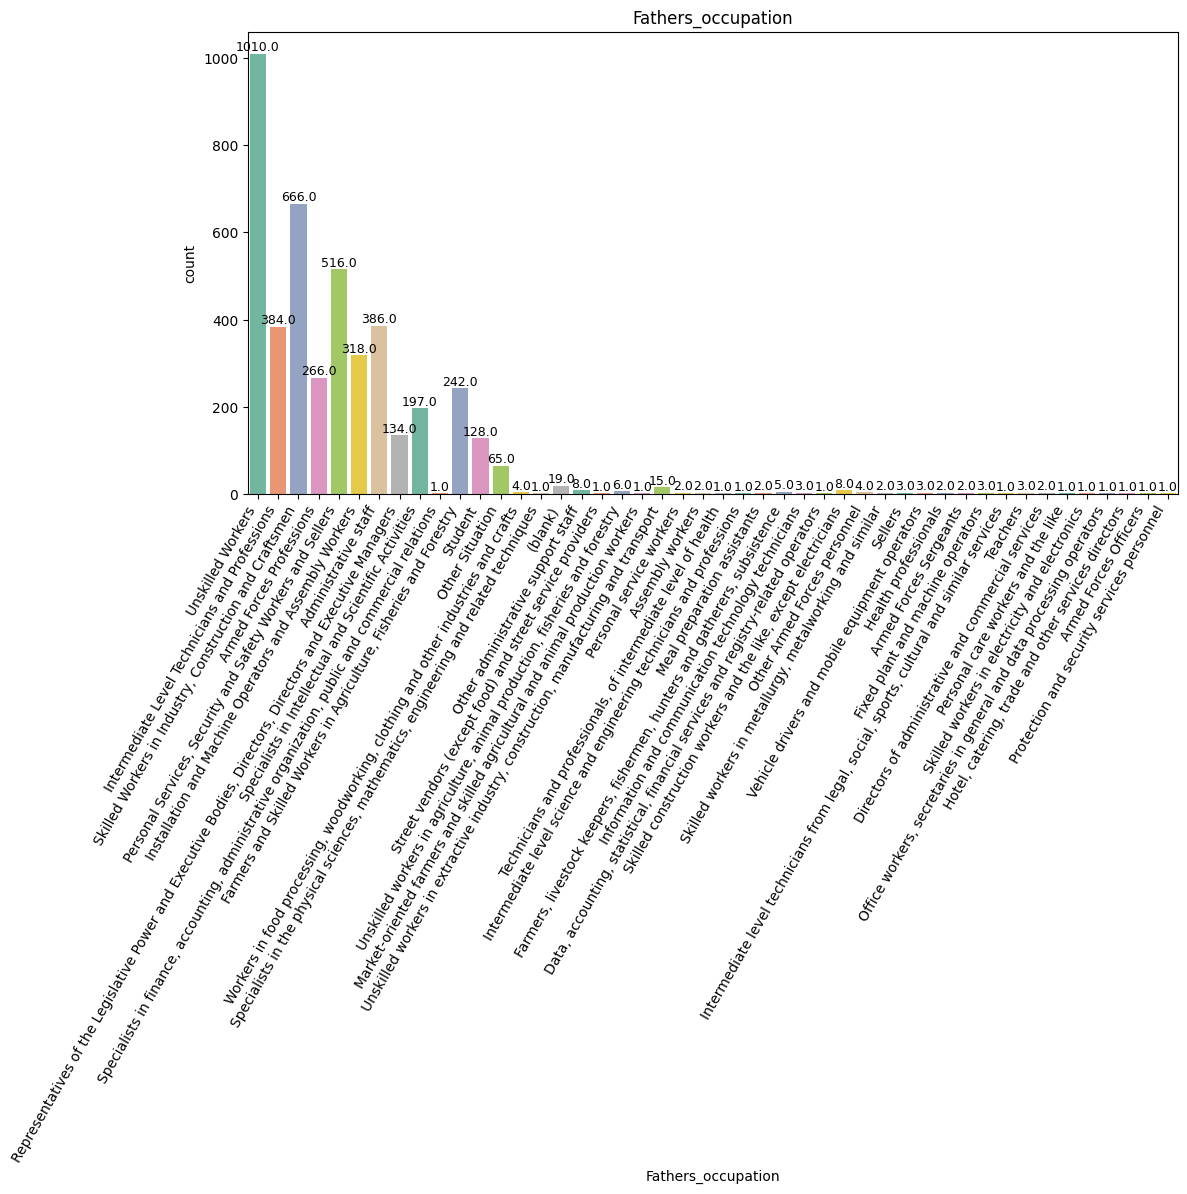

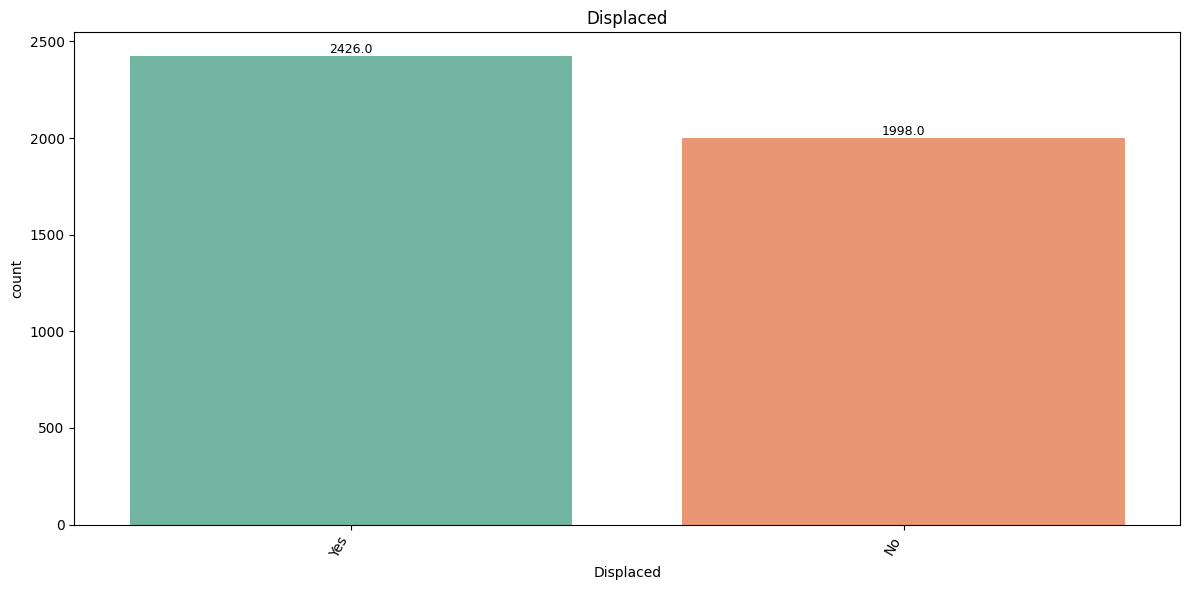

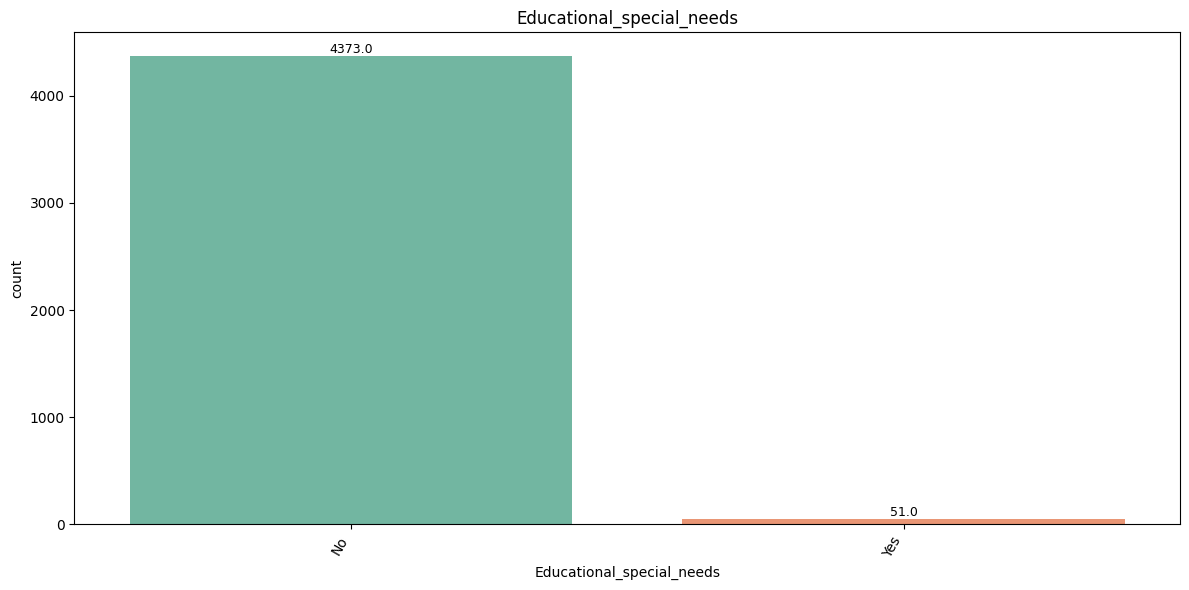

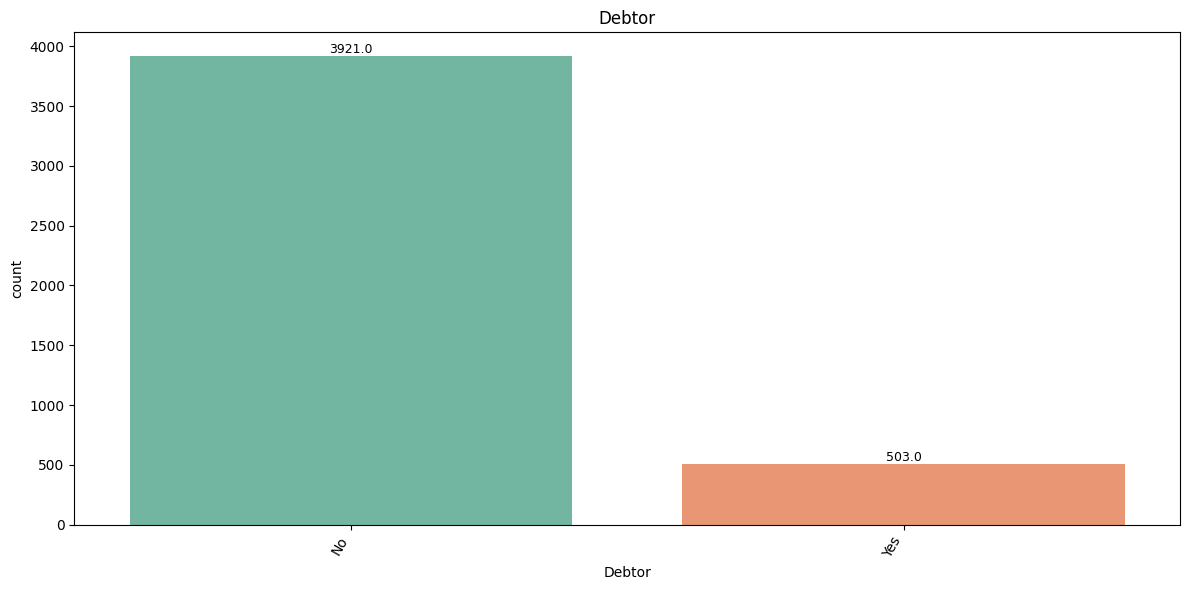

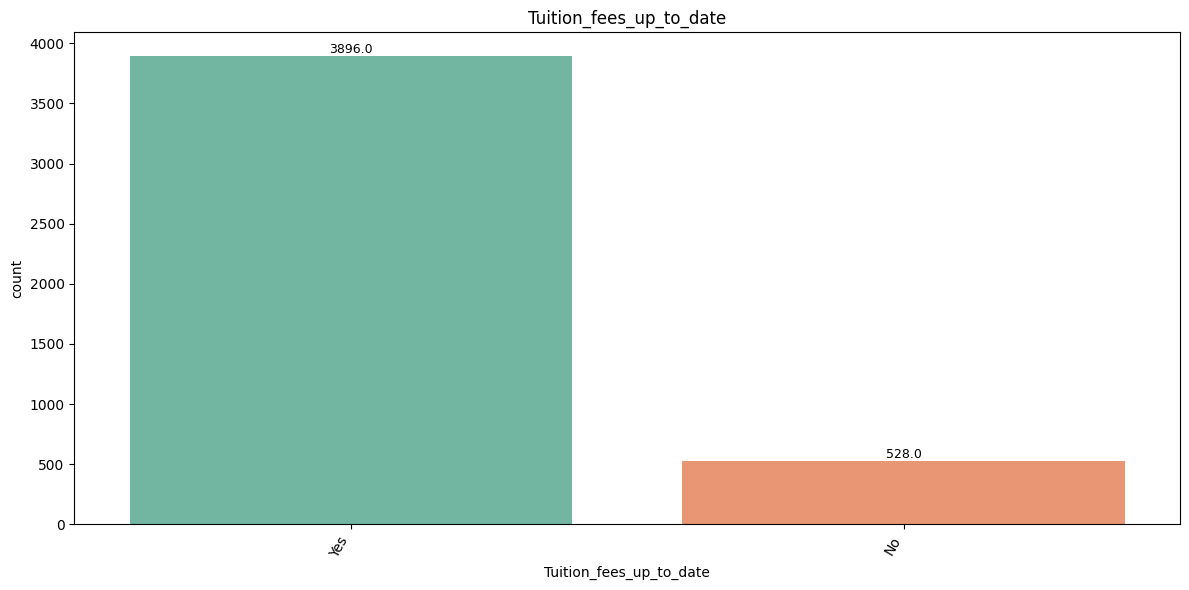

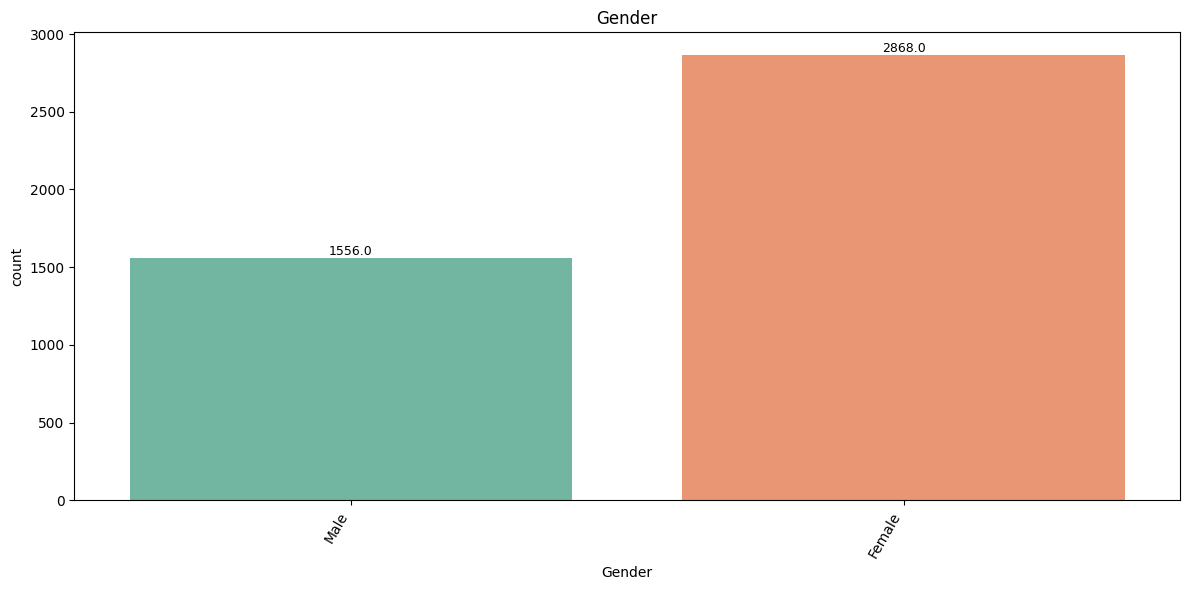

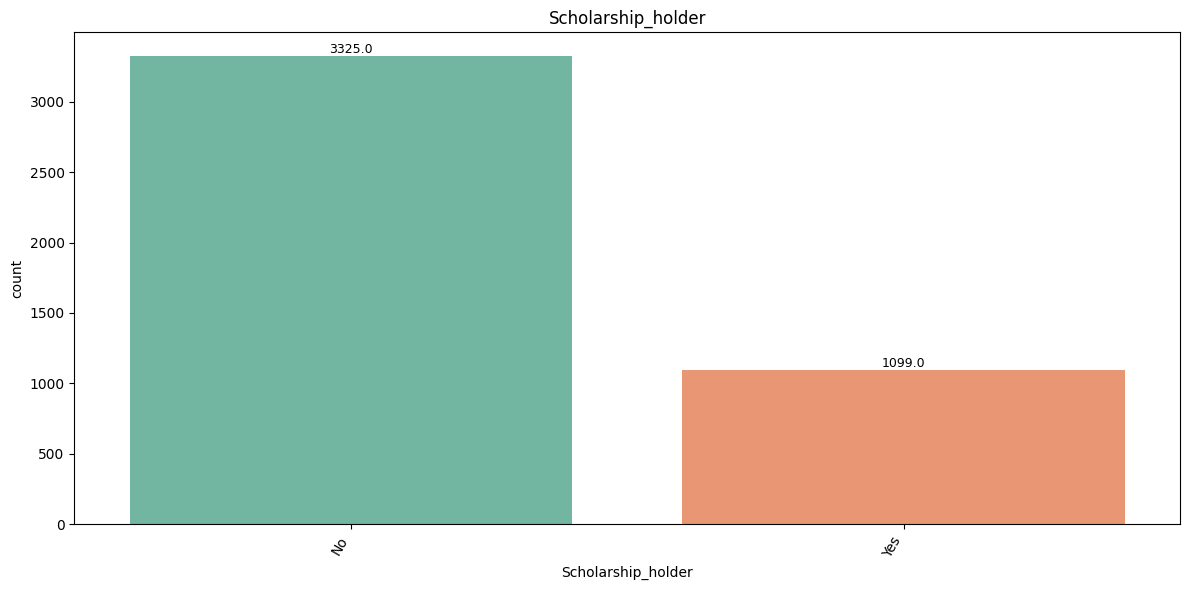

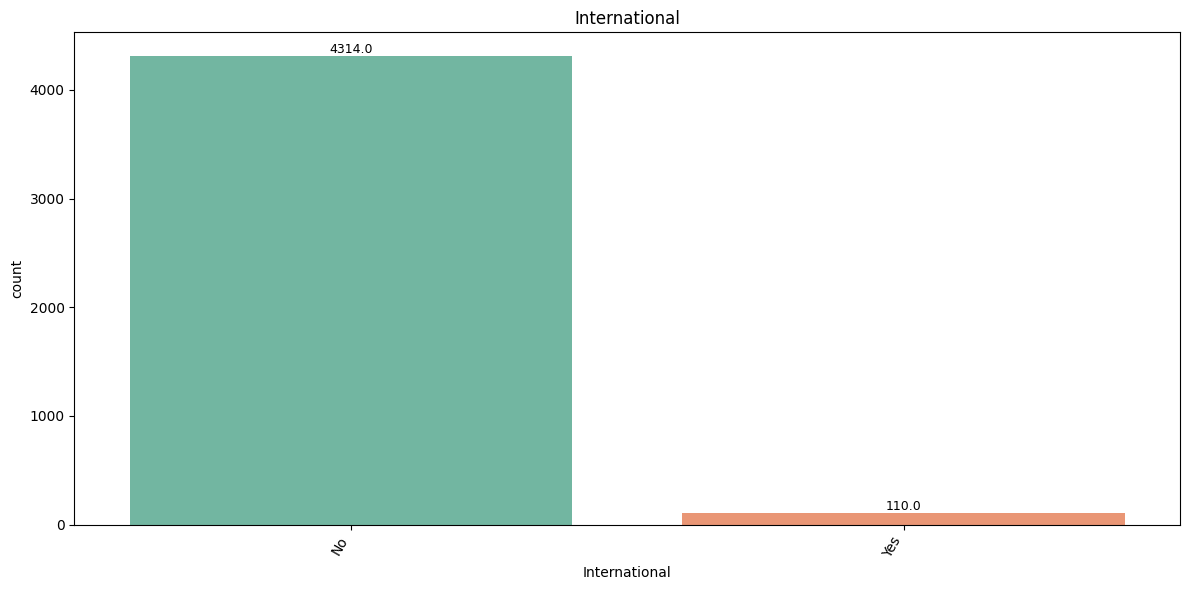

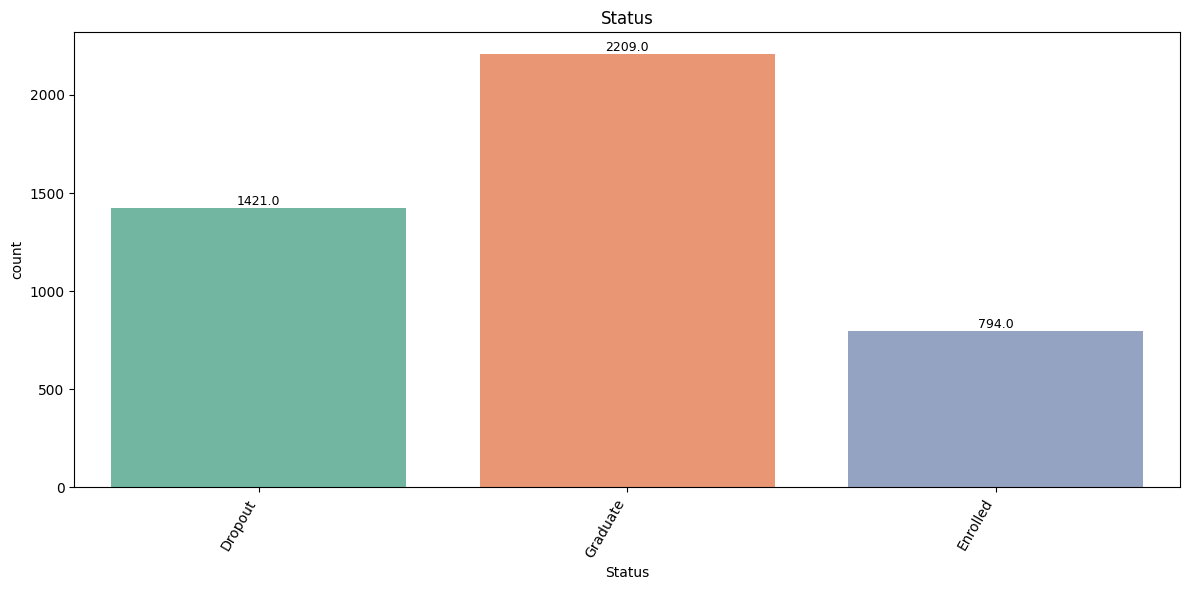

In [12]:
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(x=data_df_mapped[feature], palette='Set2')
    plt.title(feature)
    plt.xticks(rotation=60, ha='right')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


#### Univariate Numerical Analysis

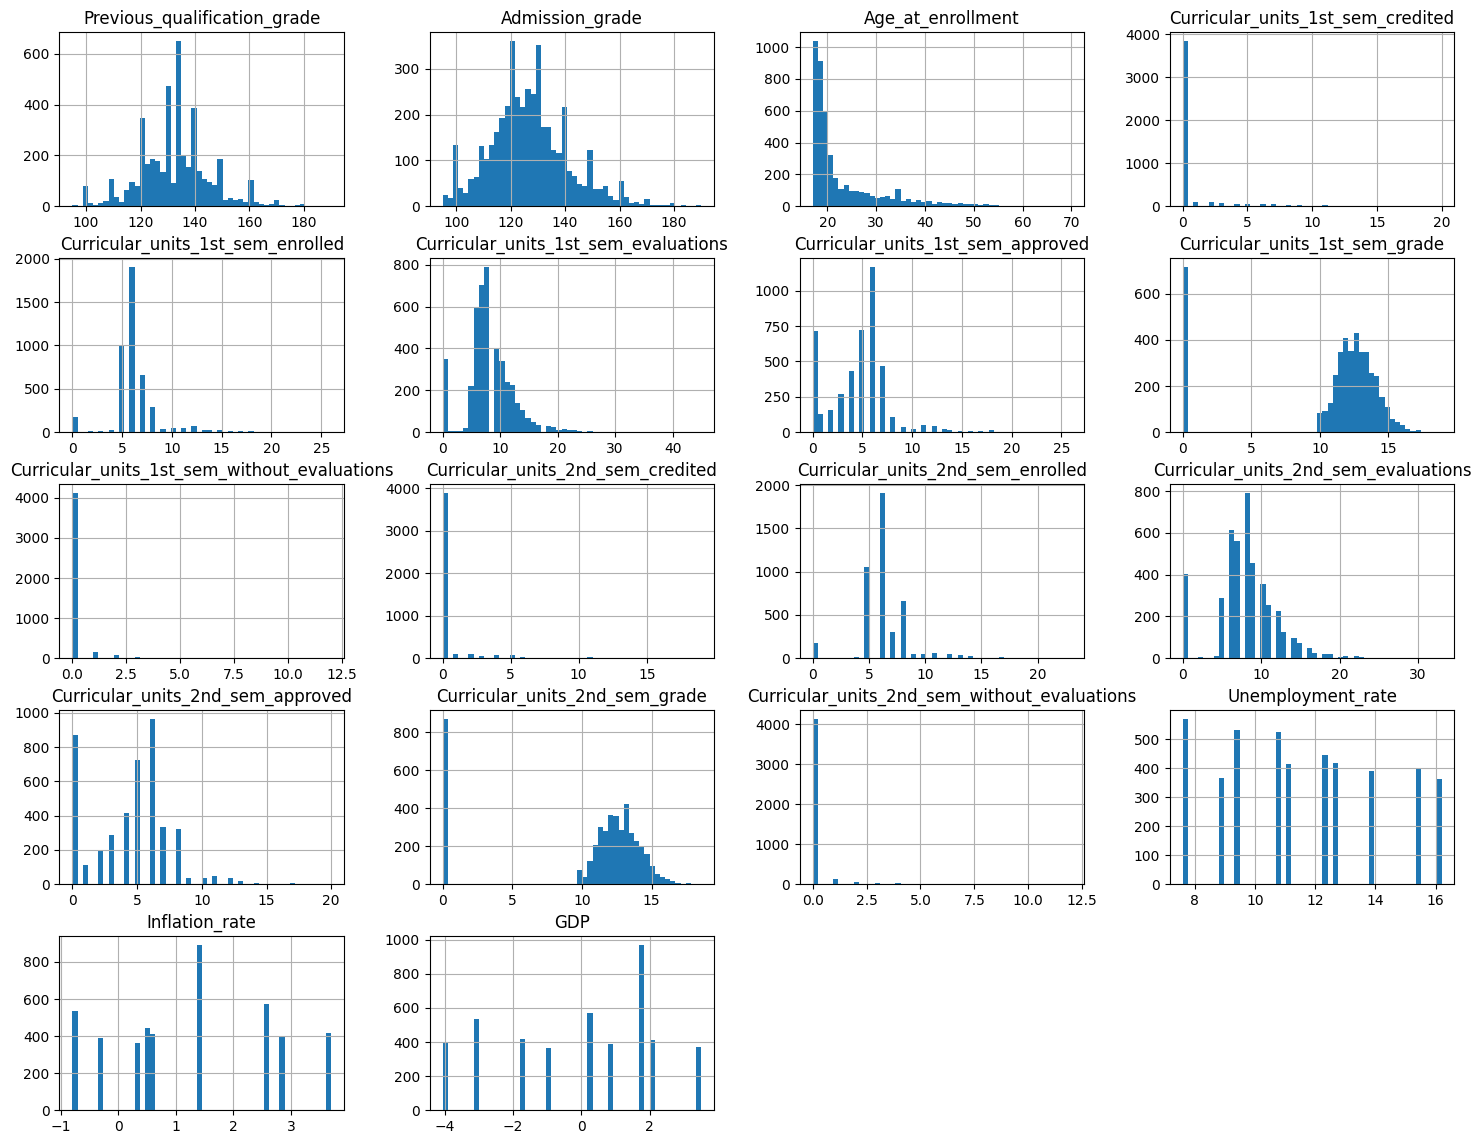

In [13]:
data_df_mapped.hist(bins=50, figsize=(18, 14))
plt.show()

Sebagian besar sebaran data adalah right-skewed

#### Multivariate Categorical Analysis

In [14]:
def categorical_multivariate(features, df, label=None):
    fig, ax = plt.subplots(len(features), 1, figsize=(16, 6 * len(features)))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        if label:
            plot = sns.countplot(data=df, x=feature, hue=label, ax=ax[i])
            ax[i].set_title(f'Distribusi {label} berdasarkan {feature}')
        else:
            plot = sns.countplot(data=df, x=feature, ax=ax[i])
            ax[i].set_title(f'Distribusi {feature}')

        ax[i].tick_params(axis='x', labelrotation=90)

        for p in plot.patches:
            height = p.get_height()
            if height > 0:
                plot.annotate(f'{height}',
                              (p.get_x() + p.get_width() / 2., height),
                              ha='center', va='bottom', fontsize=9, color='black')

        ax[i].set_ylabel(None)
        ax[i].grid(True)

    plt.tight_layout()
    plt.show()


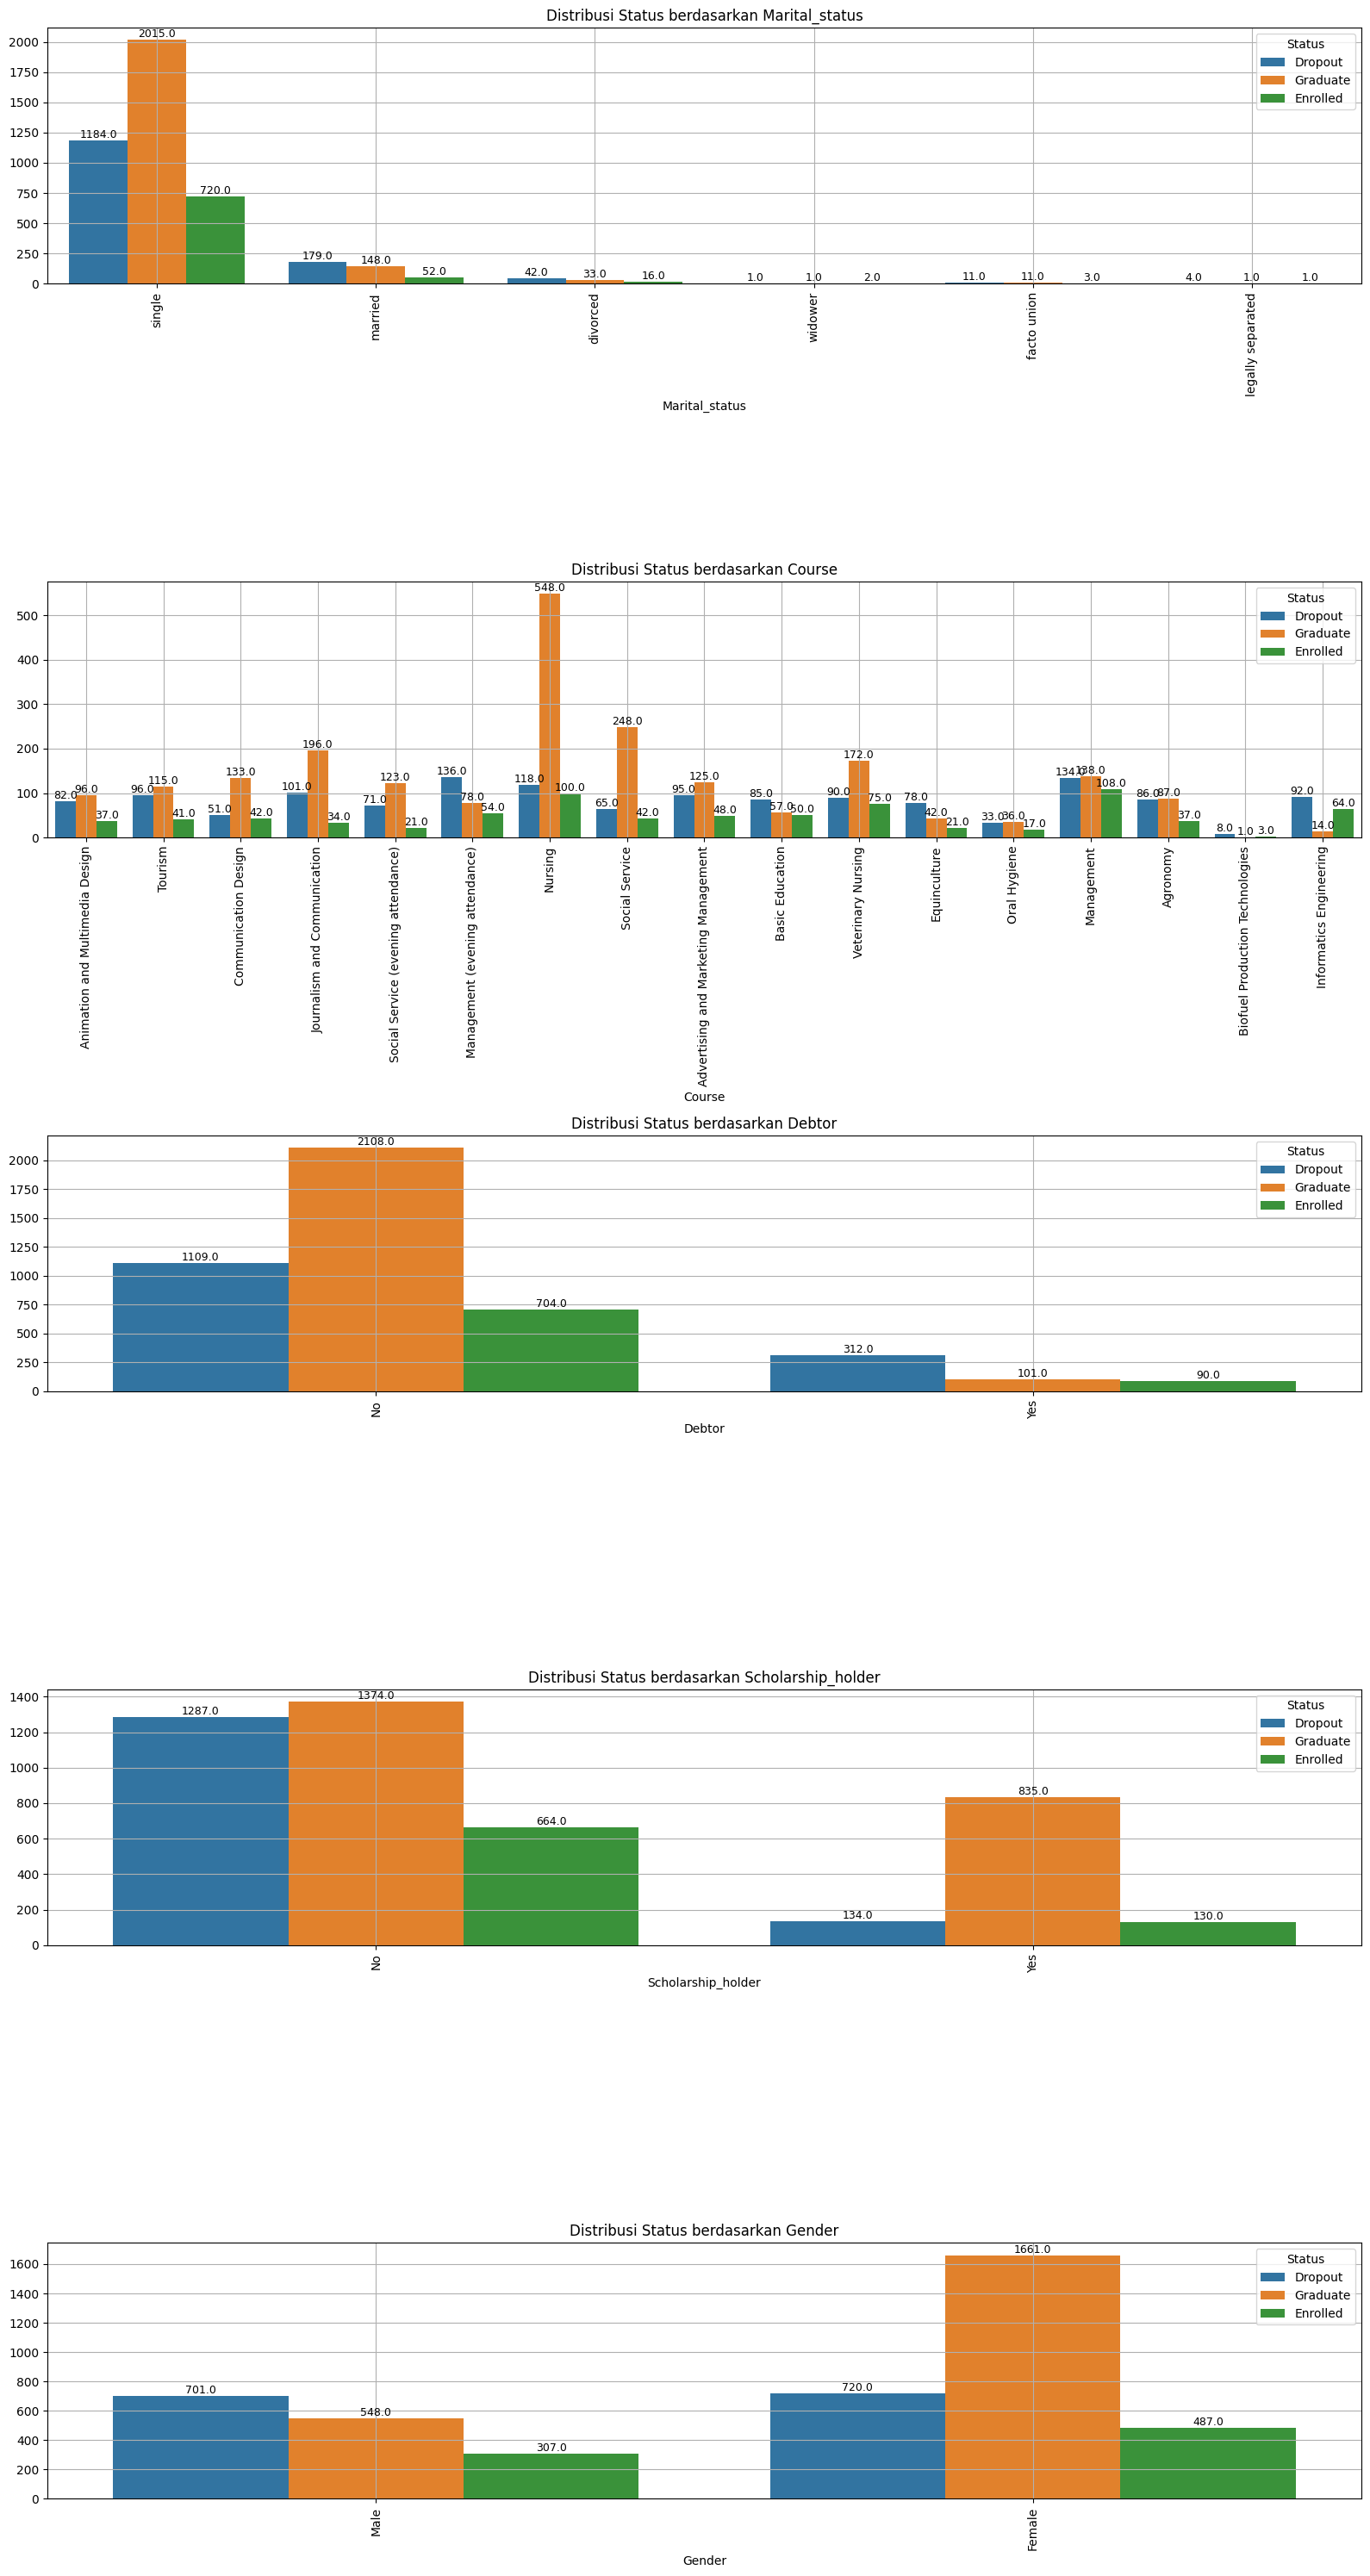

In [15]:
categorical_multivariate(
    features=['Marital_status', 'Course', 'Debtor', 'Scholarship_holder', 'Gender'],
    df=data_df_mapped,
    label='Status'
)

#### Multivariate Numerical Analysis

In [16]:
def numerical_multivariate(features, df, label=None):
    print("📦 Boxplot per fitur:")
    rows = len(features)
    fig, ax = plt.subplots(rows, 1, figsize=(14, 4 * rows))
    for i, feature in enumerate(features):
        sns.boxplot(x=df[feature], ax=ax[i], color='skyblue')
        ax[i].set_title(f'Boxplot: {feature}')
        ax[i].grid(True)
    plt.tight_layout()
    plt.show()

    print("📊 Histogram + KDE per fitur:")
    fig, ax = plt.subplots(rows, 1, figsize=(14, 4 * rows))
    for i, feature in enumerate(features):
        sns.histplot(df[feature], ax=ax[i], kde=True, color='salmon')
        ax[i].set_title(f'Histogram: {feature}')
        ax[i].grid(True)
    plt.tight_layout()
    plt.show()

    print("🔗 Korelasi antar fitur:")
    plt.figure(figsize=(12, 10))
    corr = df[features].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title("Matriks Korelasi")
    plt.tight_layout()
    plt.show()

    if label:
        print(f"📤 Hubungan fitur numerik terhadap label '{label}':")
        fig, ax = plt.subplots(rows, 1, figsize=(14, 4 * rows))
        for i, feature in enumerate(features):
            sns.boxplot(data=df, x=label, y=feature, ax=ax[i])
            ax[i].set_title(f'{feature} vs {label}')
            ax[i].grid(True)
        plt.tight_layout()
        plt.show()


In [17]:
numerical_features

['Previous_qualification_grade',
 'Admission_grade',
 'Age_at_enrollment',
 'Curricular_units_1st_sem_credited',
 'Curricular_units_1st_sem_enrolled',
 'Curricular_units_1st_sem_evaluations',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_1st_sem_grade',
 'Curricular_units_1st_sem_without_evaluations',
 'Curricular_units_2nd_sem_credited',
 'Curricular_units_2nd_sem_enrolled',
 'Curricular_units_2nd_sem_evaluations',
 'Curricular_units_2nd_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Curricular_units_2nd_sem_without_evaluations',
 'Unemployment_rate',
 'Inflation_rate',
 'GDP']

📦 Boxplot per fitur:


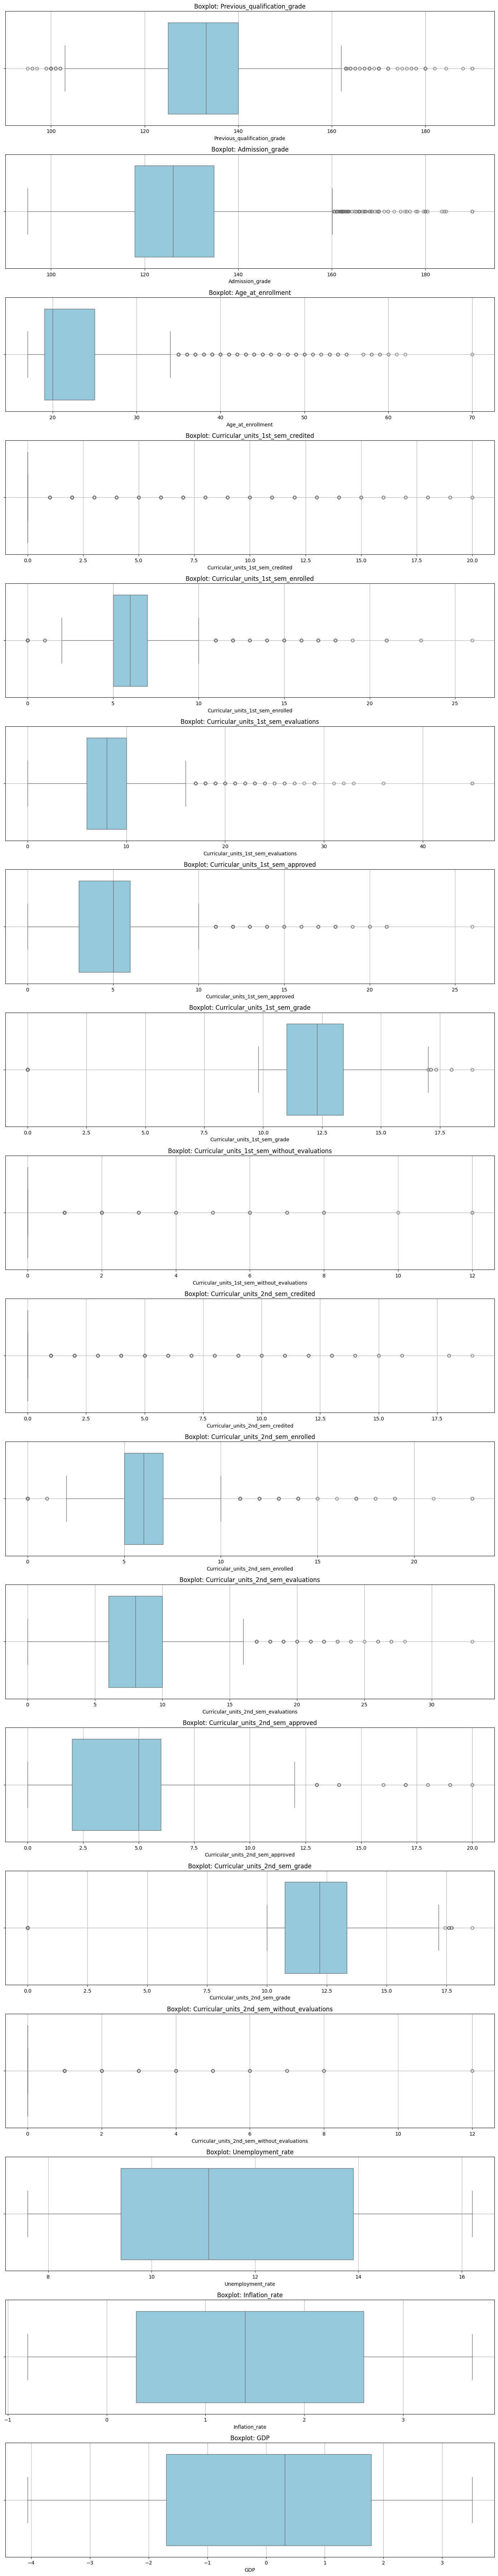

📊 Histogram + KDE per fitur:


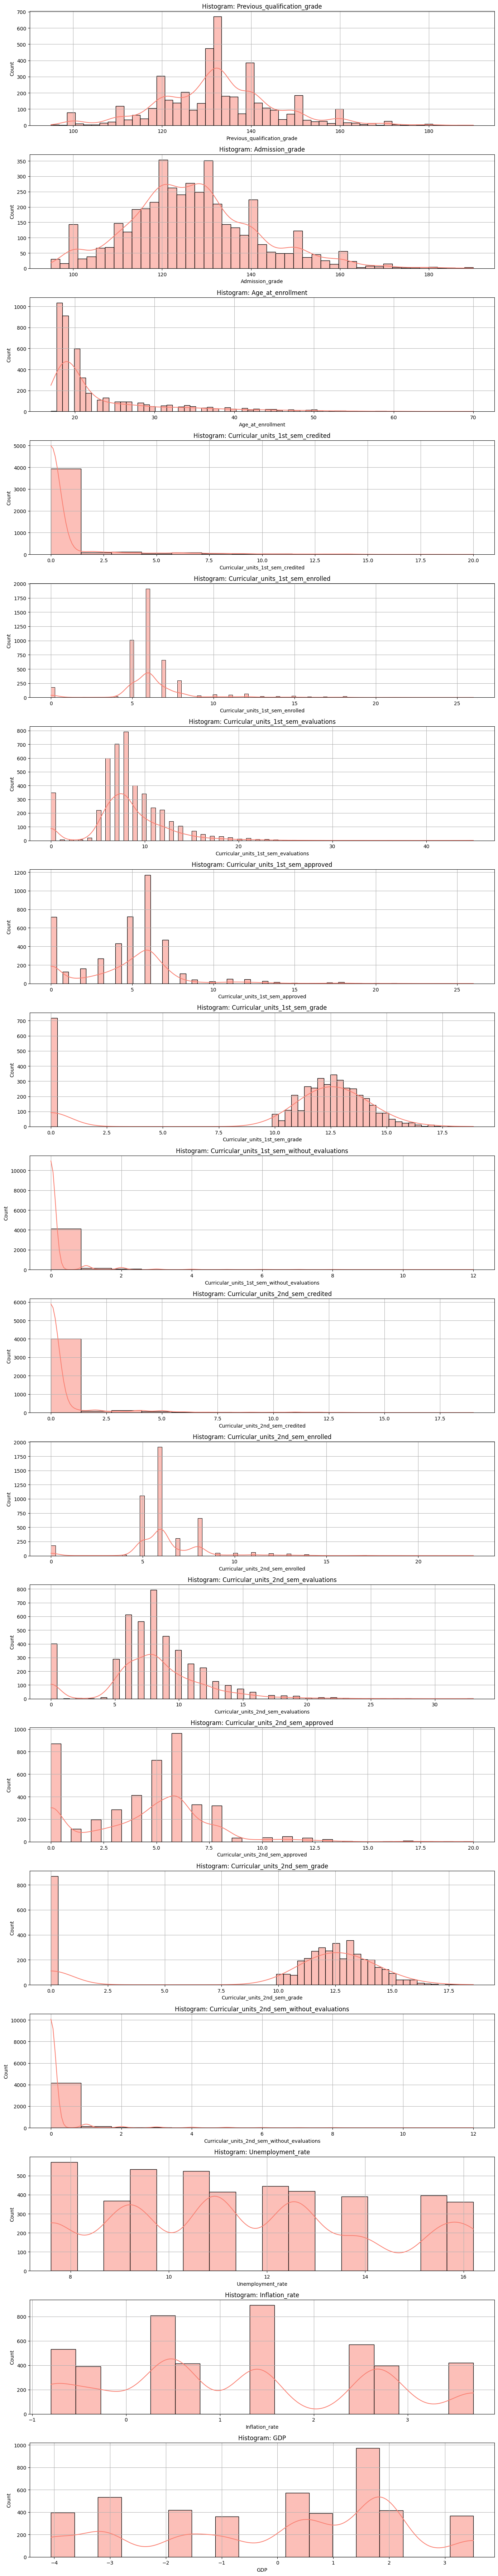

🔗 Korelasi antar fitur:


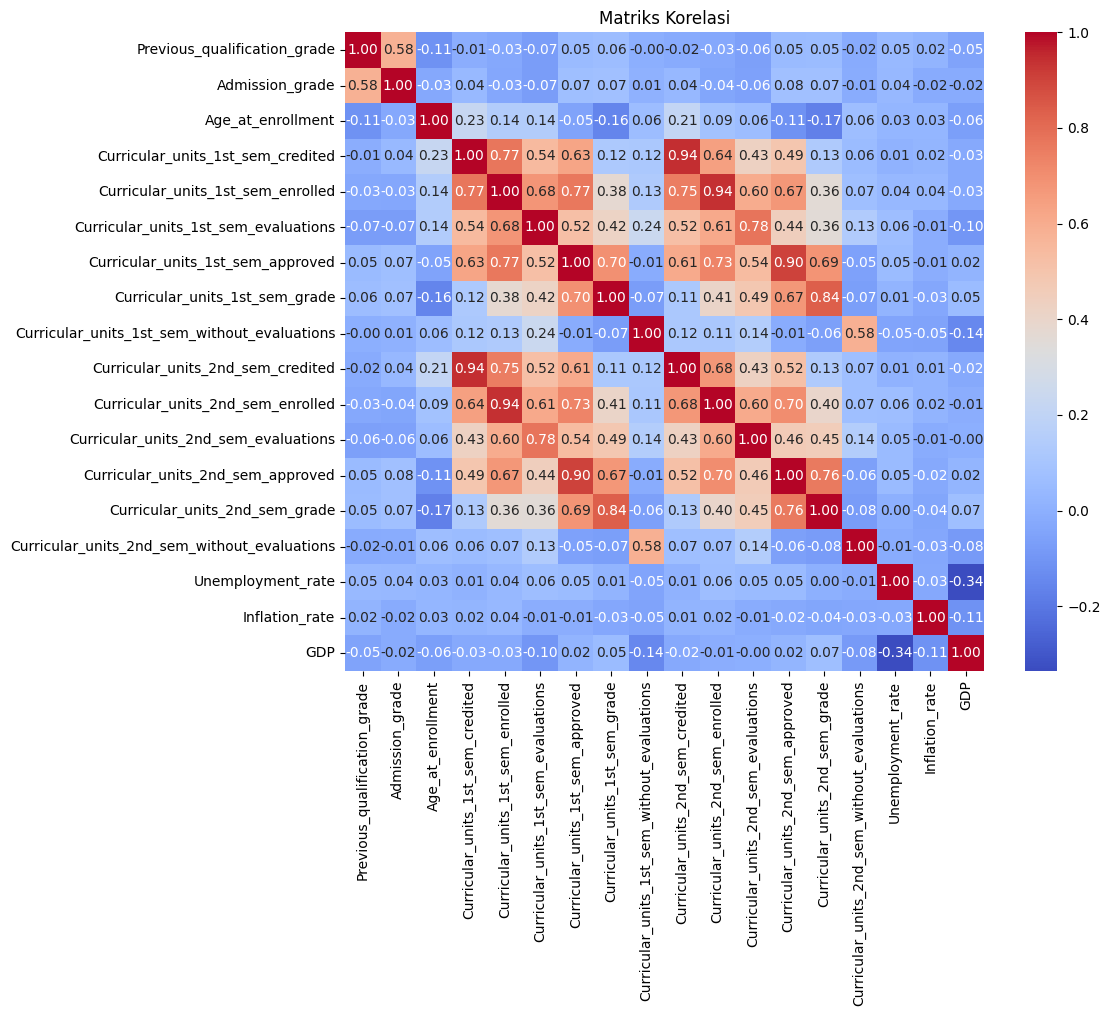

📤 Hubungan fitur numerik terhadap label 'Age_at_enrollment':


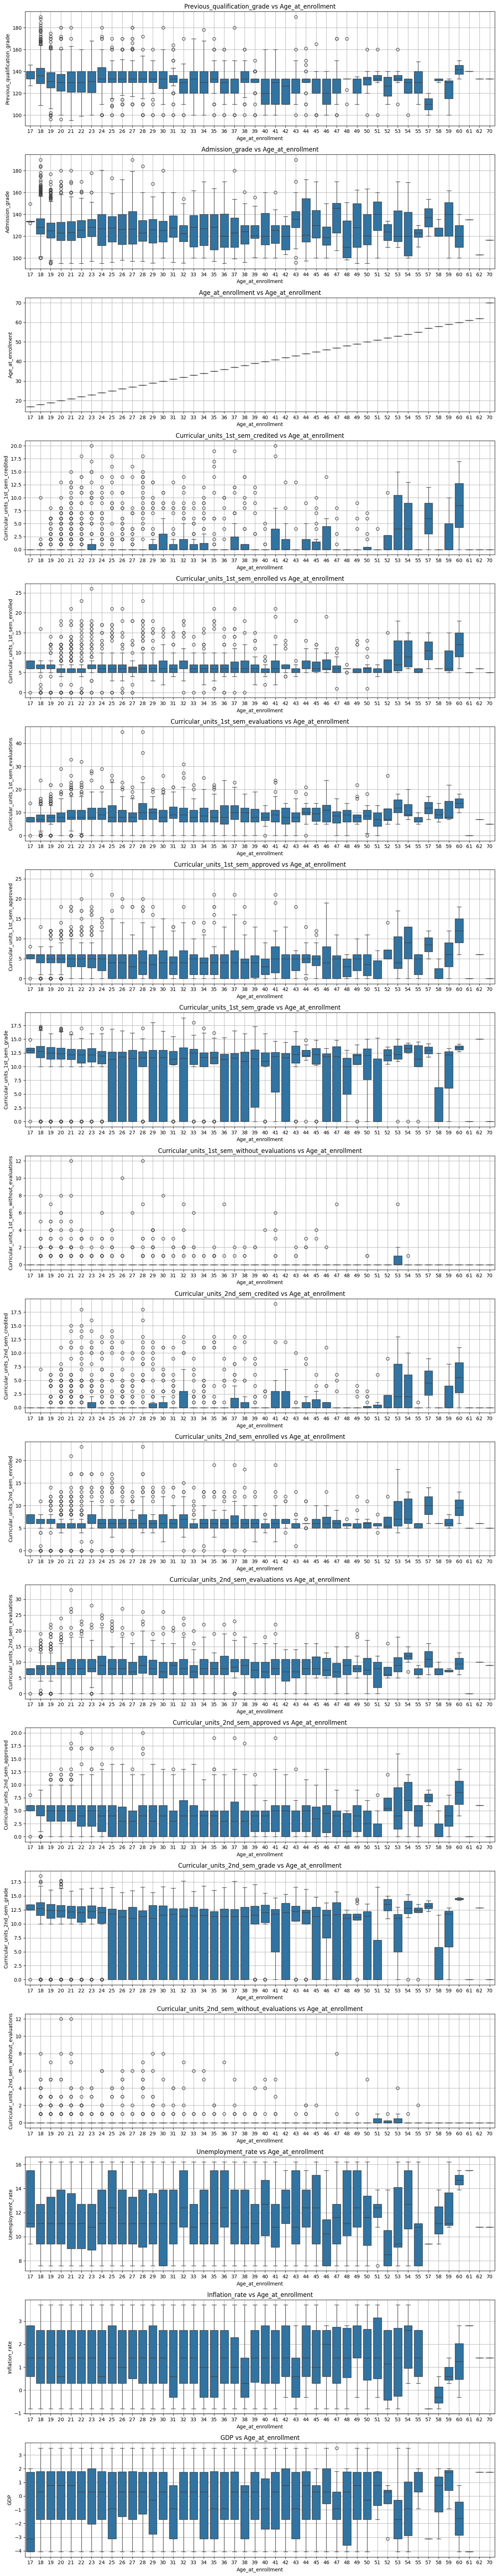

In [18]:
numerical_multivariate(numerical_features, data_df_mapped, label='Age_at_enrollment')

In [19]:
def plot_numerical_vs_categorical(num_features, cat_features, df):
    for num in num_features:
        for cat in cat_features:
            plt.figure(figsize=(12, 6))
            sns.boxplot(data=df, x=cat, y=num, palette='Set3')
            plt.title(f'Distribusi {num} berdasarkan {cat}')
            plt.xticks(rotation=45, ha='right')
            plt.grid(True)
            plt.tight_layout()
            plt.show()


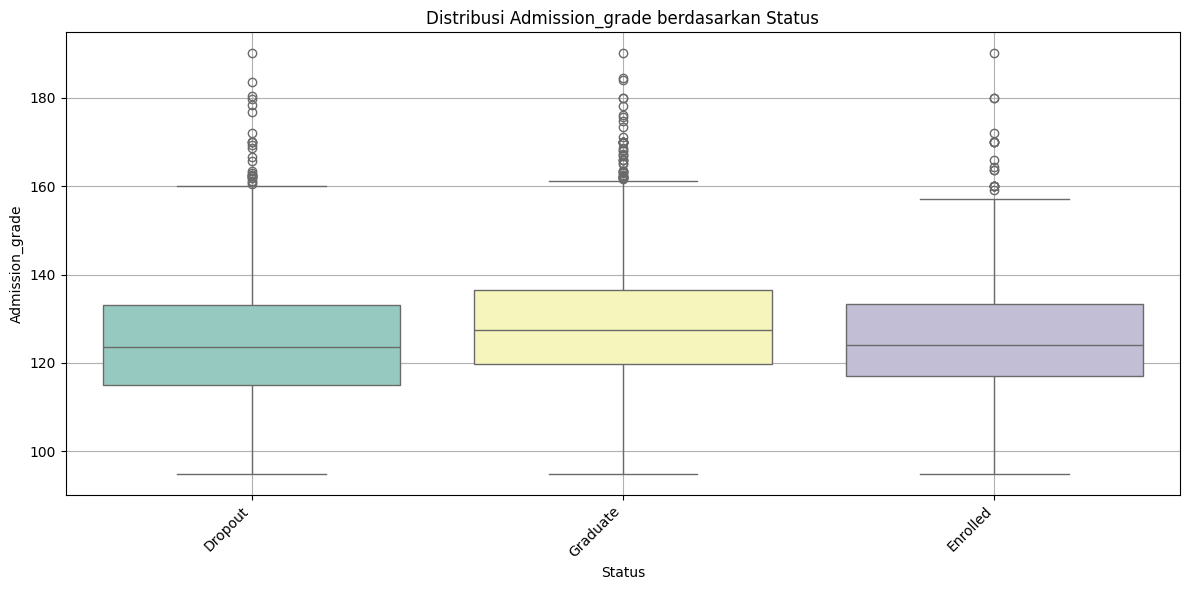

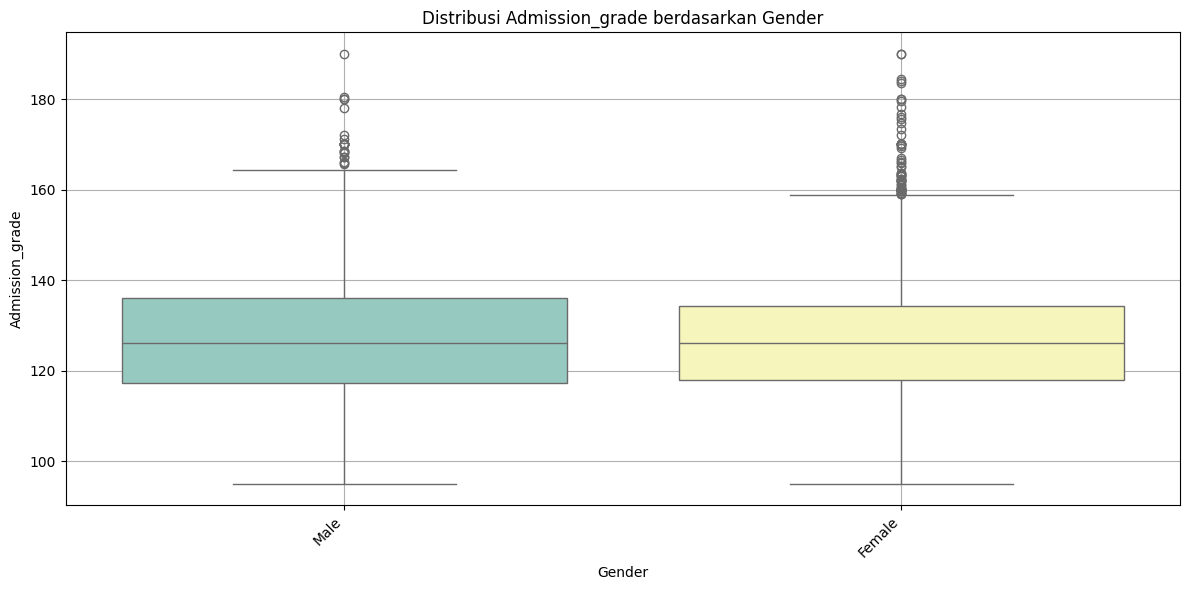

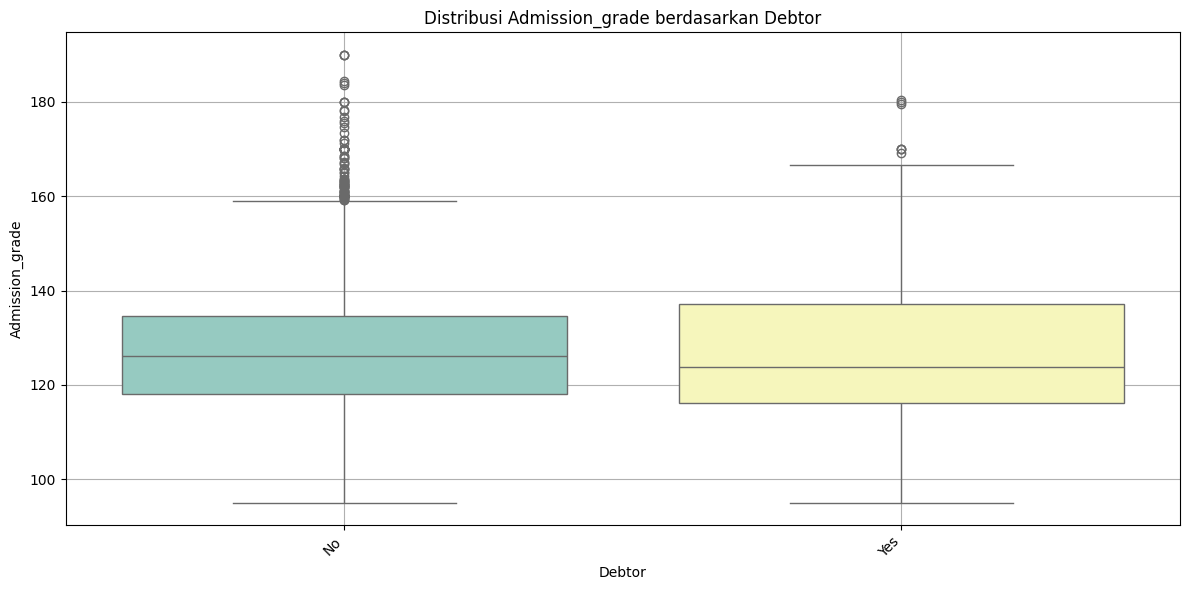

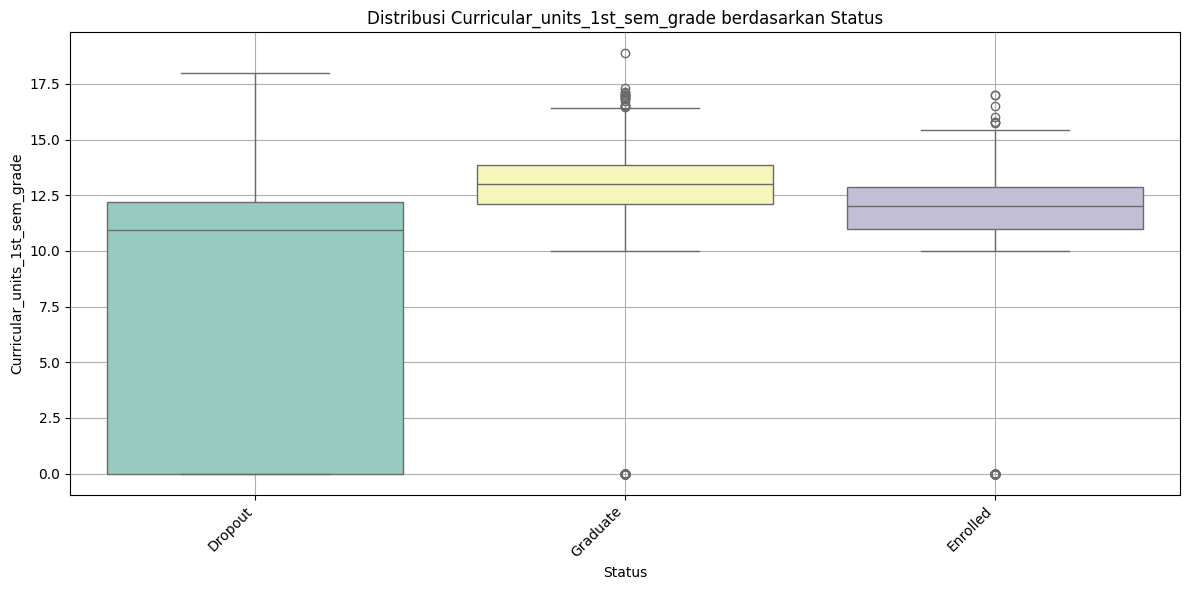

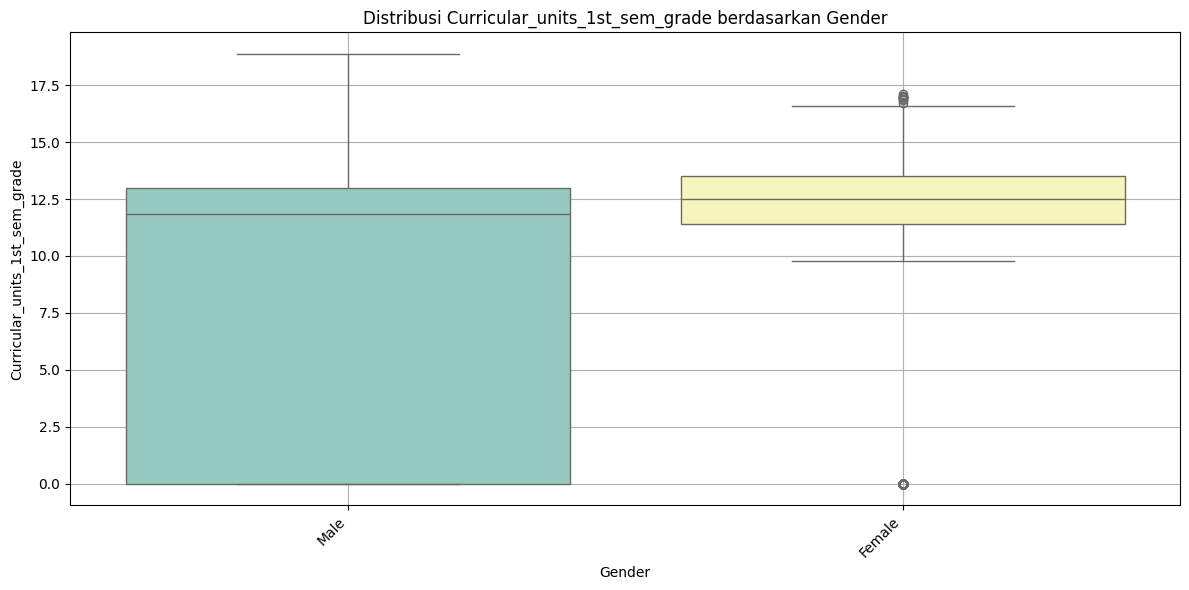

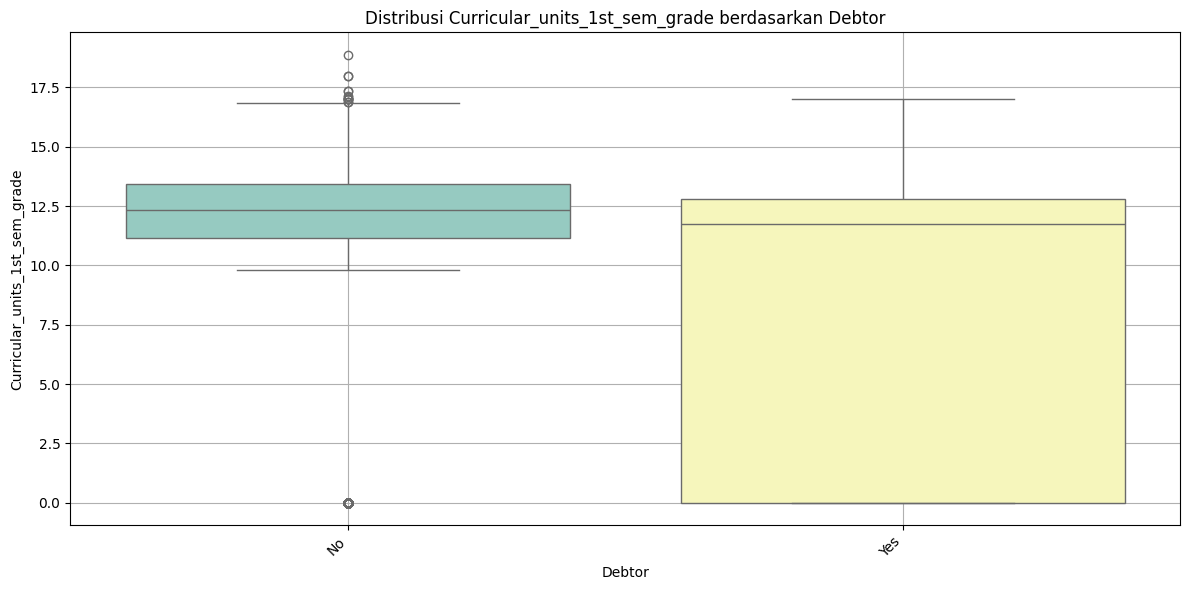

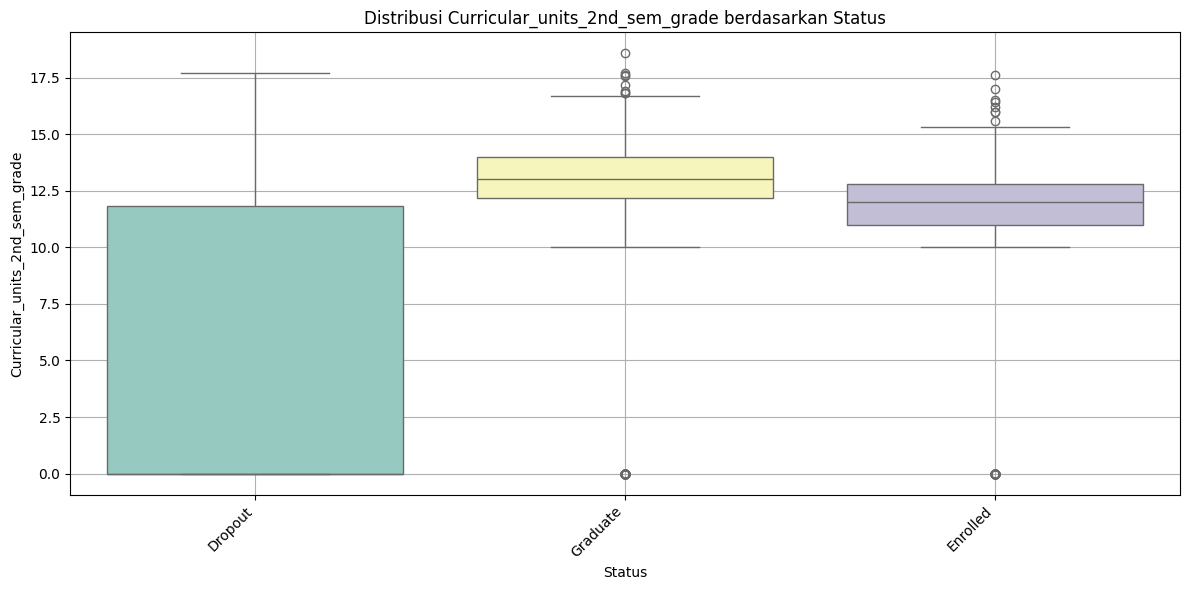

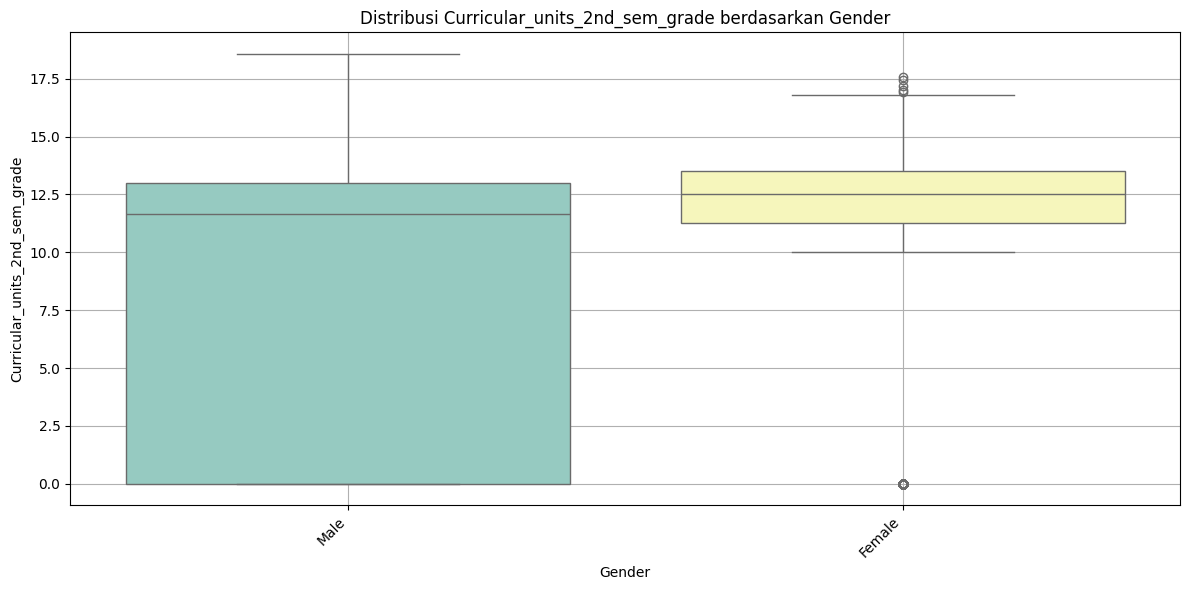

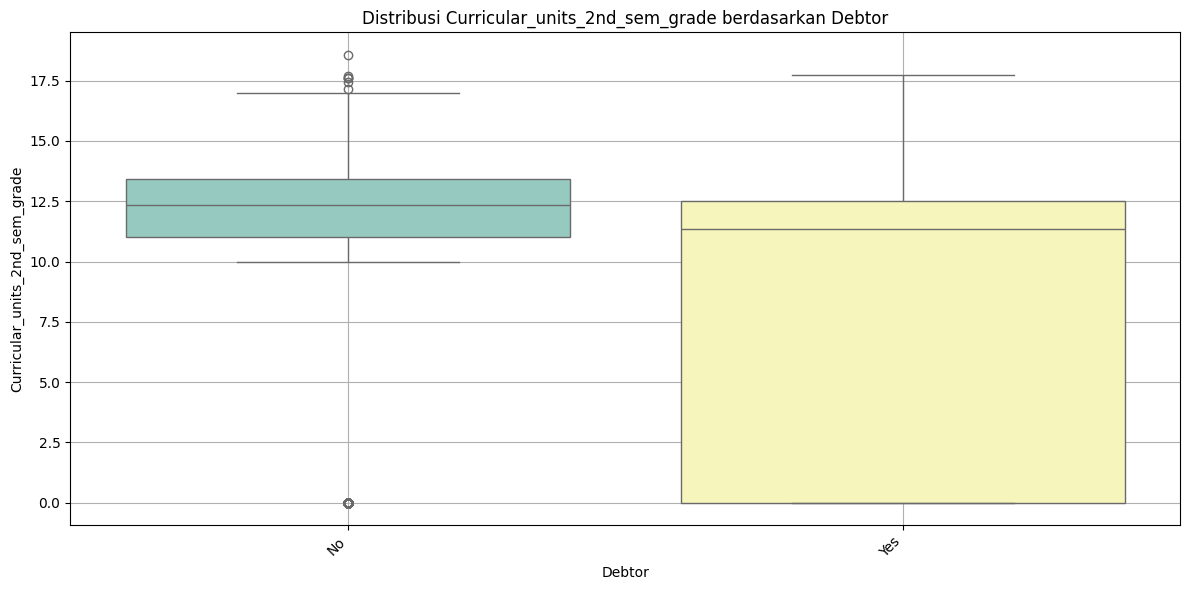

In [20]:
numerical = ['Admission_grade', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']
categorical = ['Status', 'Gender', 'Debtor']

plot_numerical_vs_categorical(numerical, categorical, data_df_mapped)


### Preprocessing

In [21]:
data_df_mapped

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,single,2nd phase - general contingent,5th choice,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),1st choice,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,5th choice,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,2nd choice,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,1st choice,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,single,1st phase - general contingent,6th choice,Journalism and Communication,daytime,Secondary education,125.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,single,1st phase - general contingent,2nd choice,Journalism and Communication,daytime,Secondary education,120.0,Russian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,single,1st phase - general contingent,1st choice,Nursing,daytime,Secondary education,154.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,single,1st phase - general contingent,1st choice,Management,daytime,Secondary education,180.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [22]:
data_df_mapped.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [23]:
numerical_features, categorical_features = [], []

for feature in data_df_mapped.columns:
    if data_df_mapped[feature].dtype == 'object':
        categorical_features.append(feature)
    else:
        numerical_features.append(feature)

In [24]:
scaler = MinMaxScaler()
data_df_mapped[numerical_features] = scaler.fit_transform(data_df_mapped[numerical_features])

In [25]:
label_encoder = LabelEncoder()
data_df_mapped[categorical_features] = data_df_mapped[categorical_features].apply(lambda x: label_encoder.fit_transform(x))

In [26]:
data_df_mapped.head(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,4,3,4,2,0,15,0.284211,14,9,26,...,0.0,0.00000,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182,0
1,4,9,0,15,0,15,0.684211,14,24,20,...,0.0,0.26087,0.181818,0.30,0.735897,0.0,0.732558,0.111111,0.640687,2
2,4,0,4,5,0,15,0.284211,14,10,11,...,0.0,0.26087,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182,0
3,4,3,1,8,0,15,0.284211,14,8,11,...,0.0,0.26087,0.303030,0.25,0.667692,0.0,0.209302,0.000000,0.124174,2
4,3,14,0,14,1,15,0.052632,14,10,9,...,0.0,0.26087,0.181818,0.30,0.700000,0.0,0.732558,0.111111,0.640687,2


In [30]:
feature = ['Marital_status', 'Course', 'Debtor', 'Scholarship_holder', 'Age_at_enrollment', 'Daytime_evening_attendance']
X = data_df_mapped[feature]
y = data_df_mapped['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3539, 6) (885, 6) (3539,) (885,)


## Modeling

In [31]:
models, accuracy, precision, recall, f1 = {}, {}, {}, {}, {}

models['LR'] = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)
models['KNN'] = KNeighborsClassifier()
models['DT'] = DecisionTreeClassifier(class_weight='balanced', random_state=42)
models['RF'] = RandomForestClassifier(class_weight='balanced', random_state=42)
models['NN'] = MLPClassifier(random_state=42)

for i in models.keys():
    models[i].fit(X_train, y_train)

    prediction = models[i].predict(X_test)

    accuracy[i] = accuracy_score(prediction, y_test)
    precision[i] = precision_score(y_test, prediction, average='weighted')
    recall[i] = recall_score(y_test, prediction, average='weighted')
    f1[i] = f1_score(y_test, prediction, average='weighted')

In [32]:
model_metrics = pd.DataFrame({
    'Accuracy': accuracy.values(),
    'Precision': precision.values(),
    'Recall': recall.values(),
    'F1-Score': f1.values()
}, index=models.keys())

model_metrics

,Accuracy,Precision,Recall,F1-Score
LR,0.437288,0.596152,0.437288,0.467071
KNN,0.545763,0.522799,0.545763,0.532352
DT,0.515254,0.556488,0.515254,0.525765
RF,0.517514,0.548443,0.517514,0.525881
NN,0.590960,0.489279,0.590960,0.529503


In [39]:
model_knn = KNeighborsClassifier().fit(X_train, y_train)
model_knn

KNeighborsClassifier()

In [40]:
y_train_knn = model_knn.predict(X_train)
y_test_knn = model_knn.predict(X_test)

## Evaluation

In [41]:
def eval_report(y_train, y_predict, name='Data'):
    print(f'Classification Report Model {name}')
    print(classification_report(y_train, y_predict))

    cm = confusion_matrix(y_train, y_predict)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Classification Report Model Training Data
              precision    recall  f1-score   support

           0       0.62      0.67      0.65      1105
           1       0.39      0.30      0.34       643
           2       0.72      0.75      0.73      1791

    accuracy                           0.64      3539
   macro avg       0.58      0.57      0.57      3539
weighted avg       0.63      0.64      0.63      3539



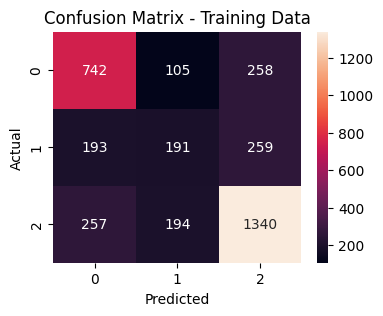

In [42]:
eval_report(y_train, y_train_knn, name='Training Data')

Classification Report Model Testing Data
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       316
           1       0.19      0.13      0.15       151
           2       0.63      0.72      0.67       418

    accuracy                           0.55       885
   macro avg       0.45      0.46      0.45       885
weighted avg       0.52      0.55      0.53       885



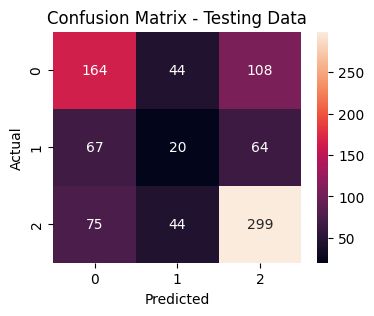

In [43]:
eval_report(y_test, y_test_knn, name='Testing Data')

In [44]:
joblib.dump(model_knn, 'model_knn.joblib')

['model_knn.joblib']

In [ ]:
!pip freeze > requirements.txt